# Creating a Hybrid CNN ViT Model for Geospatial Land Classification

## Introduction


Geospatial data analysis is a highly competitive and growing sector. It is used for land cover mapping, building roads, detection, and temporal land usage monitoring, among other applications. In this notebook, we will efficiently build a classifier by training a model from a curated dataset, apply transfer learning to enhance model performance, evaluate models using standard metrics (accuracy, F1-score, AU-ROC), and produce a professional report summarizing methodology and results. For problem formulation, we will use images to denote agricultural land vs. non-agricultural land.




## Outline
Part 1 - Data Handling
- Implement memory-based vs. generator-based data loading
- Apply data augmentation using Keras and PyTorch
- Build a custom geospatial data loader for model training

Part 2 - Convolution Neural Network Development
- Develop Keras-based and PyTorch-based CNN models
- Evaluate performance using accuracy, precision, and recall
- Compare the strengths of each framework

Part 3 - CNN - Vision Transformer Integration
- Fine-tune pre-trained transformer models in Keras and PyTorch
- Compare vision transformer performance against CNNs

Part 4 - Final Comparison
- Conduct a comparative analysis of CNN and vision transformer models

## Table of contents


1. [Setup](#setup)
2. [Part 1 - Data Handling](#part-1---data-handling)
    1. [Download Data](#download-data)
    2. [Load Images - Memory Based](#load-images---memory-based)
    3. [Load Images - Generator Based (Keras)](#load-images---generator-based-keras)
        1. [Custom Data Generator vs. In-Built Keras](#comparison-and-analysis-custom-data-generator-v-in-built-keras-utility)
    4. [Load Images - Generator Based (PyTorch)](#load-images---generator-based-pytorch)
        1. [Custom Dataset vs. In-Built ImageFolder](#comparison-and-analysis-custom-dataset-v-in-built-imagefolder)
3. [Part 2 - Convolution Neural Network Development](#part-2---convolution-neural-network-development)
    1. [Train and Evaluate a Keras-Based Classifier](#train-and-evaluate-a-keras-based-classifier)
        1. [Define the Model](#define-the-convolutional-neural-network-cnn-architecture)
        2. [Model Summary](#compile-the-model-and-display-the-summary) 
        3. [Hyperparameters](#display-the-training-configuration-and-hyperparameters)
        4. [Model Training](#execute-model-training)
        5. [Model Evaluation](#perform-a-comprehensive-model-evaluation)
        6. [Training Process Visualization](#visualize-the-training-history-accuracy-and-loss)
    2. [Implement and Test a PyTorch-Based Classifier](#implement-and-test-a-pytorch-based-classifier)
        1. [Hyperparameters](#defining-hyperparameters-and-device)
        2. [The Data Pipeline](#the-data-pipeline)
        3. [Define the Model](#defining-the-model)
        4. [Model Training](#training-and-validation)
        5. [Training Process Visualization](#visualizing-training-history)
        6. [Model Evaluation](#get-the-accuracy-of-the-model)
    3. [Comparative Analysis of Keras and PyTorch Models](#comparative-analysis-of-keras-and-pytorch-models)
        1. [Evaluation Metrics](#evaluation-metrics)
        2. [Keras Model Evaluation](#keras-model-evaluation-and-prediction)
            1. [Metrics Reporting](#keras-metrics-reporting)
        3. [PyTorch Model Evaluation](#pytorch-model-evaluation-and-prediction)
            1. [Metrics Reporting](#pytorch-metrics-reporting)
        4. [ROC Curves](#roc-curve-plotting)
        5. [Comparing Model Metrics](#comparing-model-performance)
        6. [Metric Analysis](#metric-analysis)
        7. [Model Comparison: Key Insights](#model-comparison-key-insights)
4. [Part 3 - CNN-Vision Transformer Integration](#part-3---cnn---vision-transformer-integration)
    1. [Vision Transformers in Keras](#vision-transformers-in-keras)
        1. [Custom Position Embedding Layer](#custom-positional-embedding-layer)
        2. [Transformer Block Implementation](#transformer-block-implementation)
        3. [Hybrid Model Builder Function](#hybrid-model-builder-function)
        4. [Data Generator Setup](#data-generator-configuration)
        5. [Model Architecture and Compilation](#model-architecture-and-compilation)
        6. [Model Shape Validation](#model-shape-validation)
        7. [Model Training](#train-our-hybrid_model)
        8. [Training Result Visualization](#training-results-visualization)
    2. [Vision Transformers in PyTorch](#vision-transformers-in-pytorch)
        1. [Function Definitions](#define-pre-trained-cnn-backbone)
            1. [Pre-Trained CNN Backbone](#define-pre-trained-cnn-backbone)
            2. [Patch Embedding](#patch-embedding)
            3. [Multi-head self-attention Module](#multi-head-self-attention-mhsa-module)
            4. [Transformer Block Implementation](#transformer-block)
            5. [Vision Transformer (ViT) Model](#vision-transformer-vit-model)
            6. [CNN-ViT Hybrid Model](#cnn-vit-hybrid-model)
            7. [Model Train](#model-training)
            8. [Model Evaluate](#model-evaluation)
        2. [Data Prep and Loading](#data-preparation-and-loading)
        3. [Model Initialization and Training](#model-initialization-and-training-loop)
        4. [Hyperparameter Cheatsheet (depth based)](#hyperparameter-cheatsheet-depth-based)
        5. [Training Result Visualization](#plotting-training-and-validation-accuracy-and-loss)
5. [Part 4 - Model Evaluation: Keras vs. PyTorch](#part-4---model-evaluation-keras-vs-pytorch)
    1. [PyTorch Model](#define-pytorch-model-architecture)
        1. [Dataloader](#pytorch-dataloader)
        2. [Load PyTorch Model](#----pytorch-pre-trained-vit-model-loading----)
        3. [Collect PyTorch Model Metrics](#pytorch-model-inference-metrics)
    2. [Keras Model](#keras-model-loading)
        1. [Load Keras Model](#----keras-pre-trained-vit-model-loading----)
        2. [Dataloader](#define-dataloader)
        3. [Collect Keras Model Metrics](#collecting-metrics-for-keras-based-cnn-vit-hybrid-model)
    3. [Keras Model Metrics](#keras-metrics-reporting)
    4. [PyTorch Model Metrics](#pytorch-metrics-reporting)
    5. [ROC Curve Analysis](#hybrid-model-roc-curve-plotting)
    6. [Model Performance Comparison](#comparing-hybrid-model-performance)
    7. [Hybrid Model Metric Anaylsis](#hybrid-model-metric-analysis)
6. [Closing Remarks](#closing-remarks)
7. [About](#about)

<a id="setup"></a> 

## Setup 

### Install the required libraries
Run the following cell to install required libraries, this might take a few minutes.


In [ ]:
%%capture captured_output
%%time
%pip install httpx
%pip install numpy==1.26 matplotlib==3.9.2 tensorflow==2.19 pandas==2.2.3
%pip install tensorflow==2.19 scikit-learn==1.7.0
%pip install torch==2.8.0+cpu torchvision==0.23.0+cpu torchaudio==2.8.0+cpu \
--index-url https://download.pytorch.org/whl/cpu

We can define a function to check that all libraries were installed properly.

In [6]:
# define a function to check for successful installation of the libraries
def lib_installation_check(captured_data, n_lines_print):
    """
    A function to use the %%capture output from the cells where we try to install the libraries.
    It would print last "n_lines_print" if there is an error in library installation
    """
    output_text = captured_data.stdout
    lines = output_text.splitlines()
    output_last_n_lines = '\n'.join(lines[-n_lines_print:])
    if "error" in output_last_n_lines.lower():
        print("❌ Library installation failed!")
        print("--- Error Details ---")
        print(output_last_n_lines)
    else:
        print("✅ Library installation was successful, let's proceed ahead")    

lib_installation_check(captured_data = captured_output, n_lines_print = 5)

✅ Library installation was successful, let's proceed ahead


### Import Libraries and Packges
Let's import the libraries and packages we will need for this notebook.

In [131]:
import os
import sys
import time
import shutil
import random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from datetime import datetime
def present_time():
        return datetime.now().strftime('%Y%m%d_%H%M%S')
import tensorflow as tf
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import tarfile
import httpx 
from pathlib import Path

<a id="part-1---data-handling"></a>

## Part 1 - Data Handling

<a id="download-data"></a>

### Download Data

First, we will setup the data extraction directory, then define the url to the dataset. The dataset is .tar archive hosted on a cloud object storage service.

In [8]:
extract_dir = "."
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/4Z1fwRR295-1O3PMQBH6Dg/images-dataSAT.tar"

Create a function to asynchronously download the `.tar` file using `httpx` and then extract its contents using the `tarfile` library.
- The `tarfile` module provides an interface to tar archives, supporting various compression formats such as gzip and bzip2 (handled by `r:*` mode).

In [9]:
async def download_tar_dataset(url, tar_path, extract_dir):
    """function to explicitly download and extract the dataset tar file from cloud using native python libraries
    """
    if not os.path.exists(tar_path): # download only if file not downloaded already
        try:
            print(f"Downloading from {url}...")
            async with httpx.AsyncClient() as client:
                response = await client.get(url, follow_redirects=True)# Download the file asynchronously
                response.raise_for_status() # Raise an exception for bad status codes (4xx or 5xx)
            
                with open(tar_path , "wb") as f:
                    f.write(response.content) # Save the downloaded file
                print(f"Successfully downloaded '{file_name}'.")
        except httpx.HTTPStatusError as http_err:
            print(f"HTTP error occurred during download: {http_err}")
        except Exception as download_err:
            print(f"An error occurred during the fallback process: {download_err}")
    else:
        print(f"dataset tar file already downloaded at: {tar_path}")
    with tarfile.open(tar_path, 'r:*') as tar_ref:
        tar_ref.extractall(path=extract_dir)
    print(f"✅ Successfully extracted to '{extract_dir}'.")

file_name = Path(url).name
tar_path = os.path.join(extract_dir, file_name)
print(f"tar_path: {os.path.exists(tar_path)} ___ {tar_path}")
await download_tar_dataset(url, tar_path, extract_dir)

tar_path: True ___ .\images-dataSAT.tar
dataset tar file already downloaded at: .\images-dataSAT.tar
✅ Successfully extracted to '.'.


Now, we will be able to see the **images_dataSAT** folder in our project directory. It has two folders  **class_0_non_agri** and **class_1_agri**.
The folder structure looks as follows:

```python
images_dataSAT/
├── class_0_non_agri/
└── class_1_agri/
```

**class_0_non_agri** is the non-agricultural land class, as defined earlier, and it represents images with non-cultivable land. 

**class_1_agri**, on the other hand, is the agricultural land class, and it represents the images with cultivable land.

<a id="load-images---memory-based"></a>

### Load Images - Memory Based


Next, we will use the standard approach of loading all images in memory and demonstrate how this approach is not efficient when it comes to building deep learning models for classifying images.


In [10]:
# Define directories
extract_dir = "."

base_dir = os.path.join(extract_dir, 'images_dataSAT')
dir_non_agri = os.path.join(base_dir, 'class_0_non_agri')
dir_agri = os.path.join(base_dir, 'class_1_agri')

Let's start by reading in the non_agri images. First, we will use **os.scandir** to build an iterator to iterate through the *./images_dataSAT/class_0_non_agri* directory, which contains all the images with non-agriculture land, then display the first 5 entries in the non_agri list.


In [11]:
non_agri = os.scandir(dir_non_agri)
# print first 5 file paths
for f_path in range(5):
    print(next(non_agri))


<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6248.jpg'>


Then, we will grab the first file in the directory.


In [12]:
file_name = next(non_agri)
file_name

<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6249.jpg'>

Since the directory can contain elements that are not files, we only need to read the element if it is a file.


In [13]:
os.path.isfile(file_name)

True

Get the image name.


In [14]:
image_name = str(file_name).split("'")[1]
image_name

'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6249.jpg'

Read within the image data.


In [15]:
image_data = plt.imread(os.path.join(dir_non_agri, image_name))
image_data

array([[[ 70,  68,  69],
        [ 56,  55,  53],
        [ 49,  43,  43],
        ...,
        [141, 151, 161],
        [ 80,  88,  90],
        [135, 144, 141]],

       [[ 64,  62,  63],
        [ 71,  67,  66],
        [ 81,  76,  73],
        ...,
        [213, 222, 231],
        [101, 109, 111],
        [134, 140, 136]],

       [[ 98,  94,  93],
        [106, 102,  99],
        [113, 108, 105],
        ...,
        [201, 205, 214],
        [107, 111, 112],
        [132, 137, 131]],

       ...,

       [[ 84,  84,  96],
        [ 69,  69,  81],
        [ 63,  62,  80],
        ...,
        [ 15,  24,  19],
        [ 15,  21,  21],
        [ 14,  18,  19]],

       [[ 84,  84,  94],
        [ 61,  61,  71],
        [ 70,  69,  85],
        ...,
        [ 10,  21,  15],
        [ 12,  18,  18],
        [ 12,  16,  17]],

       [[ 88,  88,  96],
        [ 59,  59,  69],
        [ 80,  79,  93],
        ...,
        [  7,  18,  12],
        [  9,  15,  15],
        [ 10,  14,  15]]

We can check the dimensinos of a single image according to **image_data**.

In [16]:
print(image_data.shape)

(64, 64, 3)


Let's take a look at the image.


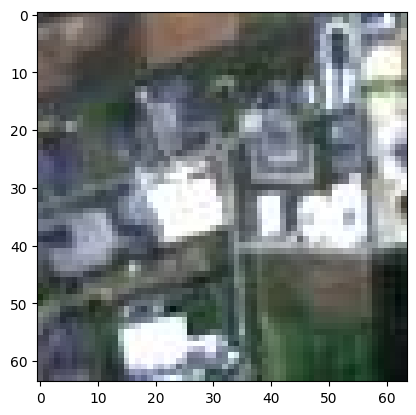

In [17]:
plt.imshow(image_data)

Now that we are familiar with the process of reading image data, let's loop through all the images in the *./images_dataSAT/class_0_non-agri* directory, read them all, and save them in the list **non_agri_images**. We will also note how long it takes to read all the images.


In [18]:
%%time

non_agri_images = []
for file_name in non_agri:
    if os.path.isfile(file_name):
        image_name = str(file_name).split("'")[1]
        image_data = plt.imread(os.path.join(dir_non_agri, image_name))
        non_agri_images.append(image_data)
    
non_agri_images = np.array(non_agri_images)

CPU times: total: 1.16 s
Wall time: 8.74 s


Loading images into memory is not the right approach when working with images, as it takes a long time or can quickly exhaust memory and other resources. Therefore, let's repeat the previous process but save the paths to the images in a variable instead of loading and saving the individual images.


So, instead of using **os.scandir**, let's use **os.listdir**.


In [19]:
non_agri_images = os.listdir(dir_non_agri)
# print first 5 file paths
non_agri_images[:5]

['tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6248.jpg']

Lets sort the list if it isn't already. We'll call the <code>sort</code> method to sort the images.


In [20]:
non_agri_images.sort()

# print first 5 file paths
non_agri_images[:5]

['tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6248.jpg']

Before we can show an image, we need to open it. We can do this by using the **Image** module in the **PIL** library. To open the first image, run the following:


In [21]:
image_data = Image.open(os.path.join(dir_non_agri, non_agri_images[0]))

To view the image, run:


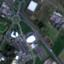

In [22]:
image_data

or use the <code>plt.imshow()</code> method as follows:


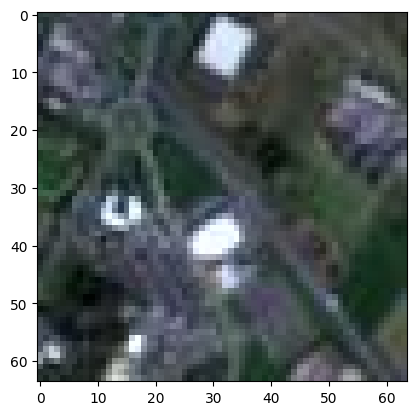

In [23]:
plt.imshow(image_data)

Let's loop through all the images in the <code>'./images_dataSAT/class_0_non_agri/'</code> directory and add their paths.


In [24]:
non_agri_images_paths = [os.path.join(dir_non_agri, image) for image in non_agri_images]
#print first five paths
non_agri_images_paths[:5]

['.\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg',
 '.\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg',
 '.\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg',
 '.\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg',
 '.\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6248.jpg']

Let's check how many images of non-agricultural land exist in the dataset.


In [25]:
len(non_agri_images_paths)

3000

Let's look at the first four images in our `'./images_dataSAT/class_0_non_agri/'` directory.


.\images_dataSAT\class_0_non_agri\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg


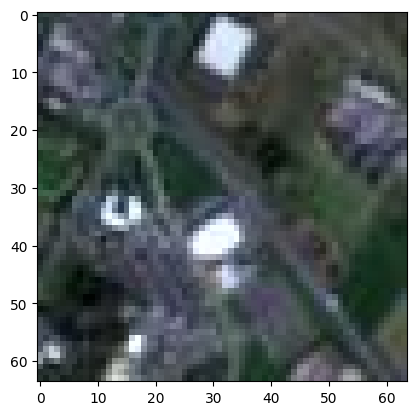

.\images_dataSAT\class_0_non_agri\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg


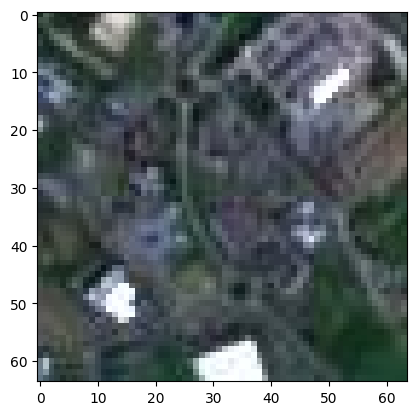

.\images_dataSAT\class_0_non_agri\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg


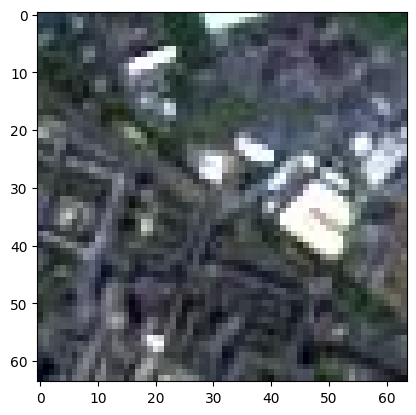

.\images_dataSAT\class_0_non_agri\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg


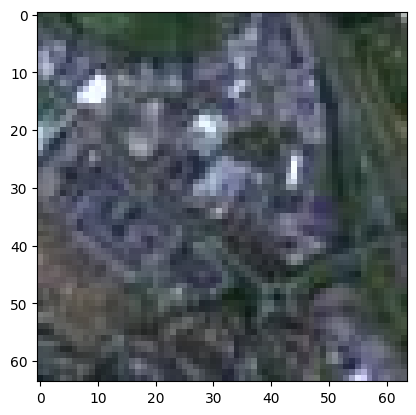

In [26]:
for path in non_agri_images_paths[:4]:
    print(path)
    image_data = Image.open(path)
    plt.imshow(image_data)
    plt.show()

Now let's save the paths to all the images in the `dir_agri` directory in a list called **agri_images_paths**, making sure to sort the paths at the end.


In [27]:
agri_images_paths = []
for image in os.listdir(dir_agri):
    agri_images_paths.append(os.path.join(dir_agri,image))

agri_images_paths.sort()

Let's see how many images of agricultural land exist in the <code>'./images_dataSAT/class_1_agri/'</code> directory.


In [28]:
print(len(agri_images_paths))

3000


Now, let's display the first four images in `'./images_dataSAT/class_0_agri/'` directory.


.\images_dataSAT\class_1_agri\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5878.jpg


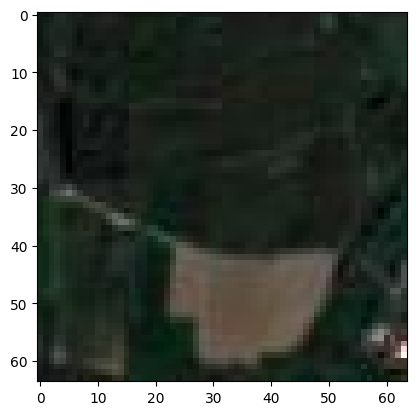

.\images_dataSAT\class_1_agri\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5884.jpg


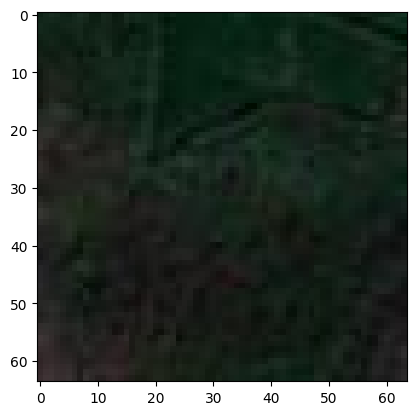

.\images_dataSAT\class_1_agri\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6628.jpg


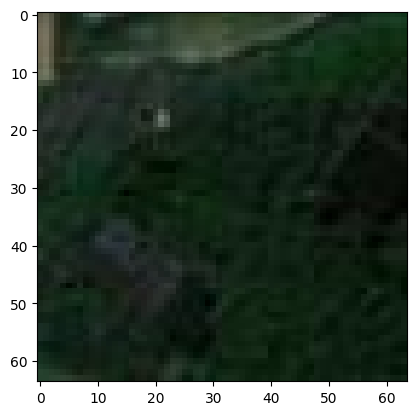

.\images_dataSAT\class_1_agri\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6629.jpg


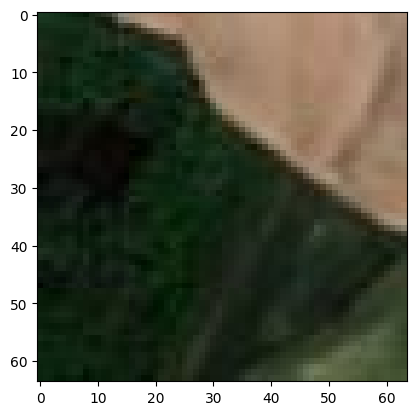

In [29]:
for path in agri_images_paths[:4]:
    print(path)
    image_data = Image.open(path)
    plt.imshow(image_data)
    plt.show()


<a id="load-images---generator-based-keras"></a>

### Load Images - Generator-Based (Keras)
#### Define Directories

In [30]:
# Define directories
base_dir = './images_dataSAT/'
# Note: It's common practice for class directories to have clear names.
# Using 'class_0' and 'class_1' is good for automatic inference.
dir_non_agri = os.path.join(base_dir, 'class_0_non_agri')
dir_agri = os.path.join(base_dir, 'class_1_agri')

Let's create a list "**all_image_paths**" containing paths of all files for both folders, *class_0_non_agri* and *class_1_agri*, in the base directory.  
For  non_agri images, assign label "0" and assign label "1" for each image in the agri folder.



In [31]:
#Initialize lists
all_image_paths = []
all_image_labels = []

#Define labels for classes
label_non_agri=0
label_agri=1

#populate lists
for fname in os.listdir(dir_non_agri):
    all_image_paths.append(os.path.join(dir_non_agri,fname))
    all_image_labels.append(label_non_agri)

for fname in os.listdir(dir_agri):
    all_image_paths.append(os.path.join(dir_agri,fname))
    all_image_labels.append(label_agri)
    
                        

We'll create a temporary list "**temp**" by binding the image paths and labels using the `zip` function.  
Then, randomly select and print 5 image paths and their corresponding labels.


In [32]:
# Use zip
temp = list(zip(all_image_paths, all_image_labels))

#Shuffle
np.random.shuffle(temp)
all_image_paths, all_image_labels = zip(*temp)

#Print 5 random paths and corresponding labels
print("First 5 paths and labels (after shuffling):", list(zip(all_image_paths[:5], all_image_labels[:5])))

First 5 paths and labels (after shuffling): [('./images_dataSAT/class_1_agri\\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_16130.jpg', 1), ('./images_dataSAT/class_0_non_agri\\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_23630.jpg', 0), ('./images_dataSAT/class_0_non_agri\\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_7931.jpg', 0), ('./images_dataSAT/class_0_non_agri\\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_18635.jpg', 0), ('./images_dataSAT/class_0_non_agri\\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_15164.jpg', 0)]


#### What is custom data generator?

A custom data generator function uses the `yield` keyword. Unlike a regular function that returns once and terminates, a generator can yield multiple values, pausing its state between each call. This "lazy evaluation" is the core principle behind memory-efficient sequential loading. For deep learning, this means we can create a generator that provides one batch of data, waits for the model to train on it, and then resumes to provide the next batch, all without loading the entire dataset into RAM.


#### Create the generator function

The `custom_data_generator` function builds an infinite Python generator that supplies mini-batches of images and labels to a Keras model during training. It accepts four arguments: `image_paths`, a list of file locations; `labels`, the corresponding class IDs; `batch_size`, the number of samples per update; and `target_size`, a tuple dictating each image’s resize dimensions. 

At the start of every epoch, in the code you create an index array equal to the dataset length, **shuffle it with NumPy**, and reorder both paths and labels identically, preserving their pairing while randomizing order. The outer `while True` loop keeps the generator alive for successive epochs. Inside, a `for` loop walks through the shuffled dataset in `batch_size` steps, slicing out `batch_paths` and `batch_labels`. For each path, `tf.keras.utils.load_img` reads the image and rescales it to `target_size`; `img_to_array` converts the PIL image to a float32 NumPy array. These arrays accumulate in `batch_images`. 

After the inner loop finishes, the batch is transformed into a NumPy array and divided by 255.0, scaling pixel values from 0–255 to 0–1, which speeds convergence and stabilizes gradients. Finally, the generator yields a tuple (`batch_images`, `batch_labels`). It supports easy augmentation and custom preprocessing.



In [33]:
def custom_data_generator(image_paths, labels, batch_size, target_size=(64, 64)):
    """A custom data generator to feed a Keras model."""
    num_samples = len(image_paths)
    while True: 
        # Shuffle data at the beginning of each epoch
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        shuffled_paths = np.array(image_paths)[indices]
        shuffled_labels = np.array(labels)[indices]
        
        # Generate batch data
        for offset in range(0, num_samples, batch_size):
            batch_paths = shuffled_paths[offset:offset+batch_size]
            batch_labels = shuffled_labels[offset:offset+batch_size]
            
            # Load and preprocess images from the batch
            batch_images = []
            for path in batch_paths:
                img = tf.keras.utils.load_img(path, target_size=target_size)
                img_array = tf.keras.utils.img_to_array(img)
                batch_images.append(img_array)
            
            # Normalize and yield the batch data
            yield np.array(batch_images) / 255.0, np.array(batch_labels)

#### Test and visualize the custom generator
Before feeding a generator to a model, it is essential to test it. 
First we instantiate `custom_data_generator` using `image_paths`, `labels` and `batch_size`, deifning the key dataloading hyperparameters.

Next we use `next(my_generator)`to get a batch of data. By calling `next(my_generator)`, we are asking the generator to execute its code until it hits the `yield` statement and to return the yielded values. This allows us to inspect a single batch to verify its shape, data types, and content. Visualizing the images with their corresponding labels, using tools like `matplotlib.pyplot.imshow`, provides a sanity check to ensure that the loading, preprocessing, and labeling logic is correct. We can display the images in two rows and 4 columns using `ax = plt.subplot(2, 4, i + 1)` code.  This ensures optimal use of resources for displaying a sample batch of images with their labels.


Let's obtain a batch of data, using batch size 8 and the `custom_data_generator` function.  
Print the batch shape for the image and label the data obtained.  
Display the images and corresponding labels using `matplotlib.pyplot` library for visual inspection.  


Image batch shape: (8, 64, 64, 3)
Labels batch shape: (8,)


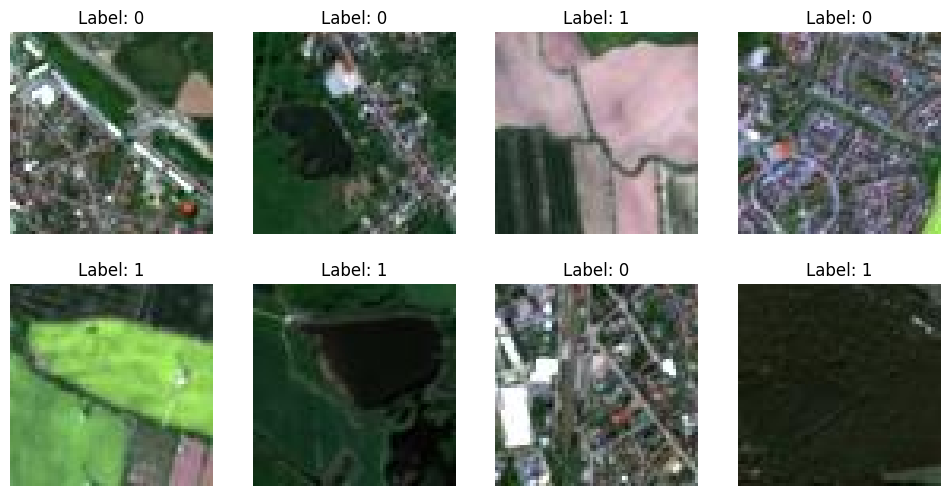

In [34]:
#define generator and parameters
batch_size = 8
my_generator = custom_data_generator(image_paths=all_image_paths, 
                                     labels=all_image_labels, 
                                     batch_size=batch_size)

#Get a batch of data
images,labels = next(my_generator)

#print batch shape for image and label obtained
print(f'Image batch shape: {images.shape}')
print(f'Labels batch shape: {labels.shape}')

#Display images and corresponding labels
plt.figure(figsize=(12,6))
for i in range(batch_size):
    ax = plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    plt.title(f'Label: {int(labels[i])}')
    plt.axis("off")

#### What is Keras' built-in utility?
Now, instead of using a custom written data generator function, let's see how the `tf.keras.utils.image_dataset_from_directory` function works. This function is built on top of the highly efficient `tf.data` library, which is TensorFlow's native solution for creating complex and performant input pipelines. This function automatically infers class labels from a standardized directory structure (e.g., `main_dir/class_a/`, `main_dir/class_b/`) and returns a `tf.data.Dataset` object. This object is extremely memory efficient and gives the symbolic representation of a data stream, which can be manipulated and optimized for maximum performance.


#### Create the training data 
We'll use the `tf.keras.utils.image_dataset_from_directory` function with image size **64 x 64** pixels and a batch size **8**.


In [35]:
IMAGE_SIZE = (64, 64)
BATCH_SIZE = 8

# Create a training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    labels='inferred',          # Labels are generated from directory structure
    label_mode='int',           # Labels are encoded as integers (0, 1, ...)
    validation_split=0.2,       # Reserve 20% of images for validation
    subset='training',          # This is the training set
    seed=1337,                  # Shuffle seed for reproducible splits
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 6000 files belonging to 2 classes.
Using 4800 files for training.


#### Create the validation data
We'll create the validation data by using the `subset` keyword in the `tf.keras.utils.image_dataset_from_directory` method.

In [36]:
#Create a validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    labels='inferred',
    label_mode='int',
    validation_split=0.2,
    subset='validation',
    seed=1337,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)   


Found 6000 files belonging to 2 classes.
Using 1200 files for validation.


#### Explore the `tf.data.Dataset` object
The `tf.data.Dataset` object is a core component of TensorFlow's data input pipeline. It represents a sequence of elements, where each element is a tuple of (images, labels). It is designed for high-throughput, parallel processing. The `.take(1)` method is used here to fetch a single element (one batch) from this data stream for inspection. Unlike our custom generator, which loaded images as NumPy arrays, this utility loads them as TensorFlow Tensors, which is the native data type for TensorFlow operations.


Class names inferred by Keras: ['class_0_non_agri', 'class_1_agri']


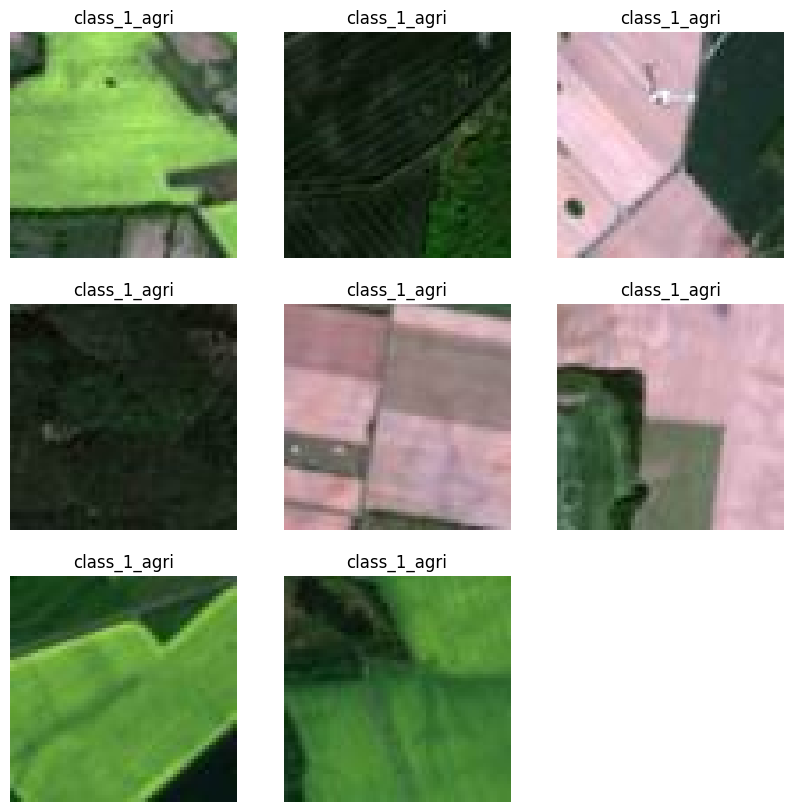

In [37]:
print(f"Class names inferred by Keras: {train_ds.class_names}")

# Let's visualize one batch from the training dataset
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):  # Take one batch
    for i in range(BATCH_SIZE):
        ax = plt.subplot(3, 3, i + 1)
        # Images are loaded as float32, so we convert to uint8 for display
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

#### Configure the dataset for performance

The dedicated utility, `tf.data.Dataset`, can be chained with various methods to create a highly performant pipeline. 
- **`.map(function)`:** Applies a given function to every element of the dataset. Here, it is used to apply data augmentation layers. TensorFlow can automatically parallelize this operation.
- **`.cache()`:** Caches the dataset in memory after it's loaded from disk during the first epoch. For subsequent epochs, data will be read from the faster memory cache, significantly speeding up training. This is **only feasible if** the dataset fits in RAM.
- **`.prefetch(buffer_size)`:** It allows the data preprocessing (done on the CPU) to happen in parallel with the model training (done on the GPU). While the GPU is busy with the current batch, the CPU is already preparing the next batch. This overlapping of tasks prevents the GPU from sitting idle and waiting for data, a phenomenon known as an I/O bottleneck.
- **`AUTOTUNE`** lets TensorFlow dynamically decide the optimal buffer size for your computer.


In [38]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
])

# Apply augmentation to the training dataset using map
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# Configure for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Dataset is now configured for high performance!")

Dataset is now configured for high performance!


<a id="comparison-and-analysis-custom-data-generator-v-in-built-keras-utility"></a>

#### Comparison and Analysis (Custom Data Generator v. In-Built Keras Utility)

We've now seen two ways to create a data loader in Keras. This comparison highlights the engineering trade-offs between control and convenience.


| Feature                  | Custom data generator                                       | In-built Keras utility (`image_dataset_from_directory`)     |
|--------------------------|-------------------------------------------------------------|-------------------------------------------------------------|
| **Ease of use**          | Low. Requires significant boilerplate code for loops, shuffling, and batching. | High. A single, intuitive function call handles everything. |
| **Code complexity**      | High. You manually manage file paths, labels, loading, and preprocessing. | Low. The function abstracts away all the complexity.          |
| **Flexibility**          | Very high. You can implement any custom logic for loading or non-standard data structures. | Moderate. Designed for a standard directory structure (`class/images`), but very flexible within that. |
| **Features**             | Basic. Shuffling, augmentation, and validation splits must be coded manually. | Rich. Built-in shuffling, batching, and validation splits. Seamless integration with Keras preprocessing layers. |
| **Performance**          | Poor to moderate. A simple Python generator can become an I/O bottleneck for the GPU due to its single-threaded nature. | Excellent. Creates a `tf.data.Dataset` object, which is highly optimized and can be configured with `.cache()` and `.prefetch()` for maximum throughput. |
| **Recommended for**      | Learning purposes or highly specialized, non-standard datasets (e.g., loading from a database or a custom binary format). | **Almost all standard image classification tasks.**         |


<a id="load-images---generator-based-pytorch"></a>

### Load Images - Generator-Based (PyTorch)

#### Define the directories


In [39]:
# Define directories
base_dir = os.path.join(extract_dir, 'images_dataSAT')
dir_non_agri = os.path.join(base_dir, 'class_0_non_agri')
dir_agri = os.path.join(base_dir, 'class_1_agri')

#### Custom PyTorch `Dataset`

In PyTorch, 
- A `Dataset` object is an iterable (gives one sample at a time).

- A `DataLoader` is an iterator that returns batches (adds a batch dimension: `[B, C, H, W]`).

- To create a custom dataset, we will create a class that inherits from `torch.utils.data.Dataset` and implements three essential methods:
- `__init__(self)`: This method is run once when the dataset is instantiated. It's where you perform initial setup, such as loading file paths and labels.
- `__len__(self)`: This returns the total number of samples in the dataset.
- `__getitem__(self, idx)`: This method is responsible for loading and returning a *single* sample from the dataset at the given index `idx`. This is the core of sequential loading; it fetches one data point from storage "just-in-time".


In [40]:
class CustomBinaryClassDataset(Dataset):
    """A custom dataset for our agricultural land classification task."""
    def __init__(self, non_agri_dir, agri_dir, transform=None):
        """
        Args:
            non_agri_dir (string): Directory with all the non-agricultural images.
            agri_dir (string): Directory with all the agricultural images.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.transform = transform
        self.image_paths = []
        self.labels = []

        # Load non-agri paths and assign label 0
        for fname in os.listdir(non_agri_dir):
            self.image_paths.append(os.path.join(non_agri_dir, fname))
            self.labels.append(0)
            
        # Load agri paths and assign label 1
        for fname in os.listdir(agri_dir):
            self.image_paths.append(os.path.join(agri_dir, fname))
            self.labels.append(1)

        temp = list(zip(self.image_paths, self.labels))
        np.random.shuffle(temp)
        self.image_paths, self.labels = zip(*temp)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB") # Ensure image is in RGB format
        
        label = self.labels[idx]
        
        # Apply transformations if they exist
        if self.transform:
            image = self.transform(image)
            
        return image, label

#### Define transformations

- `torchvision.transforms` provides a suite of common image transformations. These are used for preprocessing (such as `resizing` and `converting to a tensor`) and data augmentation (such as `random flips` and `rotations`).
- `transforms.Compose` chains these operations together into a single, callable pipeline. Data augmentation is a crucial regularization technique that helps prevent overfitting by showing the model slightly different versions of the same image at each epoch.
- Transforms like `RandomFlip` and `Rotation` work on PIL images and must be applied before `ToTensor()`, which converts images to tensors.
- `Normalize()` scales tensor values (e.g., from `[0, 1]` to `[-1, 1]`) using `(x - mean) / std`  or can be based on model you are fine tuining


In [41]:
test_transform = transforms.Compose([transforms.Resize((128, 128)),
                                     transforms.RandomHorizontalFlip(),
                                     transforms.RandomRotation(20),
                                     transforms.ToTensor(), # Converts PIL Image to a tensor and scales values to [0, 1]
                                     transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5]) # Normalize to [-1, 1]
])

Now that we know how a data augmentation pipeline works in PyTorch, let’s create a transformation pipeline `custom_transform`for the given specifications:


    1. image size = 64 x 64 pixels
    2. RandomHorizontalFlip probability 0.5
    3. RandomVerticalFlip probability 0.2
    4. RandomRotation of 45 degrees

Then, transform it to tensor and normalize it to [-1, 1]


In [42]:
custom_transform = transforms.Compose([transforms.Resize((64,64)),
                                       transforms.RandomHorizontalFlip(p=0.5),
                                       transforms.RandomVerticalFlip(p=0.2),
                                       transforms.RandomRotation(45),
                                       transforms.ToTensor(), 
                                       transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5]) # Normalize to [-1, 1]
                                      ])

#### In-built `ImageFolder` utility

For datasets that follow a standard `root/class_name/xxx.ext` directory structure, PyTorch provides `torchvision.datasets.ImageFolder`. This is a specialized `Dataset` class that does all the work of finding image paths and inferring class labels for you. It's the most convenient way to load image datasets organized in folders, where each subfolder represents a different class.

**ImageFolder** acts as a quick bridge between raw image files and PyTorch models. We can point the `root` argument at the top-level dataset folder, and the class automatically walks through every subfolder, using each subfolder’s name as a label. We can attach a `transform pipeline` with common choices including `transforms.Resize`, `transforms.CenterCrop`, `transforms.ToTensor`, and `transforms.Normalize` to pre-process every image on the fly. Calling `len(dataset)` reveals total images, while indexing `dataset[i]` returns an `(image, label)` pair. We can then combine it with `DataLoader` to batch, shuffle, and parallel-load data effortlessly.

**ImageFolder** works on the `dataset folder` structured as represented below:

    dataset/
    ├── class1/
    │   ├── image1.jpg
    │   └── image2.jpg
    └── class2/
        ├── image3.jpg
        └── image4.jpg
    

From this dataset, we can create a `dataset object` like this: 

```
# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Load dataset
dataset = datasets.ImageFolder(
    root='path/to/dataset',
    transform=transform

```

Then, we can use this `dataset object` to create a `dataloader` like this:
```
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

for images, labels in dataloader:
    # Your training code here
    .
    .
    ...

```
This `dataloader` can then be used for creating batches of images for training / testing of the model.

**`ImageFolder`** automatically assigns numerical labels to classes based on folder names alphabetically. Access class names via `dataset.classes` and class-to-index mapping via `dataset.class_to_idx`


Let's get the dataset **imagefolder_dataset** using `datasets.Imagefolder` method and applying **custom_transform**


In [43]:
imagefolder_dataset = datasets.ImageFolder(root=base_dir,
                                           transform=custom_transform)


Next, let's print the name and the class index. 

In [44]:
print(f'Classes found: {imagefolder_dataset.classes}')
print(f'Class to index mapping: {imagefolder_dataset.class_to_idx}')


Classes found: ['class_0_non_agri', 'class_1_agri']
Class to index mapping: {'class_0_non_agri': 0, 'class_1_agri': 1}


#### The `DataLoader` - Bringing it all together

The `DataLoader` is an iterator that returns batches, based on the `batch_size`. It wraps a `Dataset` object and provides an iterable to access the data. Its key responsibilities are:
- **Batching:** This involves grouping individual samples into mini-batches.
- **Shuffling:** This involves randomly shuffling the data every epoch to prevent the model from learning the order of samples. The data loading process is parallelized, preventing the CPU from becoming a bottleneck for the GPU.

We can use the `DataLoader` with **both** our `CustomBinaryClassDataset` and the `ImageFolder` dataset.

Linear and convolution layers in a neural network can work **with or without** the batch dimension 
- e.g., with shapes `[C, H, W]` or  `[B, C, H, W]`, where:
    - `B`: `batch_size`
    - `C`: `number of channels`
    - `H`: `image height`
    - `W`: `image width`


In [45]:
BATCH_SIZE = 8 #  the number of images in a batch (batch size)

# --- Using your Custom Dataset ---
custom_dataset = CustomBinaryClassDataset(dir_non_agri, dir_agri, transform=custom_transform)
custom_loader = DataLoader(custom_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

# --- Using the ImageFolder Dataset ---
imagefolder_loader = DataLoader(imagefolder_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

print("DataLoaders created successfully!")

DataLoaders created successfully!


#### Visualize a batch

Let's inspect a batch from our `DataLoader`. We can use `iter()` and `next()` to pull a single batch. This is exactly what a training loop does under the hood. Visualizing the images and their labels confirms that our entire pipeline (from path loading and transformation to batching) is working correctly.


In [46]:
# Get one batch from the Custom loader
images_custom, labels_custom = next(iter(custom_loader))

print(f"Images batch shape (Custom loader): {images_custom.shape}") 
print(f"Labels batch shape (Custom loader): {labels_custom.shape}")


Images batch shape (Custom loader): torch.Size([8, 3, 64, 64])
Labels batch shape (Custom loader): torch.Size([8])


Let's get a batch of images and labels from the `imagefolder_loader` and print their shape.


In [47]:
images_inbuilt, labels_inbuilt = next(iter(imagefolder_loader))
print(f'Images Batch Shape (using ImageFolder): {images_inbuilt.shape}')
print(f'Labels Batch Shape (using ImageFolder): {labels_inbuilt.shape}')

Images Batch Shape (using ImageFolder): torch.Size([8, 3, 64, 64])
Labels Batch Shape (using ImageFolder): torch.Size([8])


Next, we define a function to display an image from the batch. 


In [48]:
def imshow(img):
    """Helper function to un-normalize and display an image"""
    img = img / 2 + 0.5  # Un-normalize from [-1, 1] to [0, 1]
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0))) # Convert from C,H,W to H,W,C

Then, display the images in the PyTorch in-built loader batch.


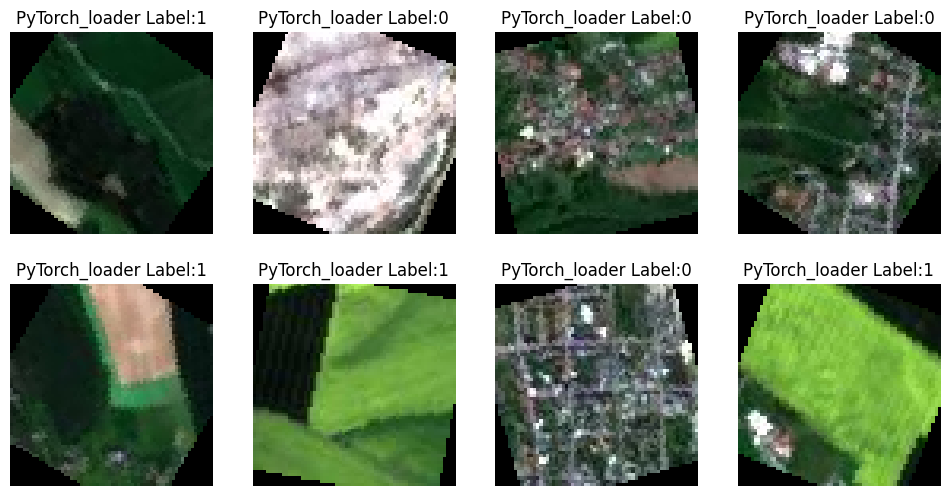

In [49]:
plt.figure(figsize = (12, 6))
for i in range(BATCH_SIZE):
    ax = plt.subplot(2, 4, i + 1)
    imshow(images_inbuilt[i])
    plt.title(f"PyTorch_loader Label:{labels_inbuilt[i].item()}")
    plt.axis("off")    

Similar to the code cell above, we can display the images stored in `images_custom` generated using `custom_loader`. 

The title of the images will be **`Custom_loader Label: `** similar to the images seen in the above cell


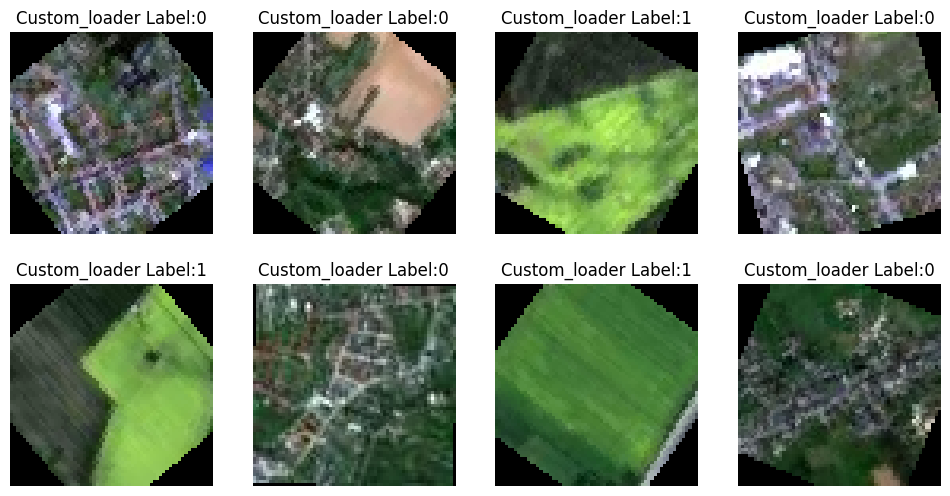

In [50]:
plt.figure(figsize=(12,6))
for i in range(BATCH_SIZE):
    ax = plt.subplot(2,4,i+1)
    imshow(images_custom[i])
    plt.title(f'Custom_loader Label:{labels_custom[i].item()}')
    plt.axis('off')

<a id="comparison-and-analysis-custom-dataset-v-in-built-imagefolder"></a>

#### Comparison and Analysis (Custom Dataset v. In-Built ImageFolder)

In PyTorch, both methods lead to a `DataLoader`. The key difference lies in how the underlying `Dataset` is created.


| Feature                  | Custom `Dataset`                                       | In-built `ImageFolder`     |
|--------------------------|-------------------------------------------------------------|-------------------------------------------------------------|
| **Ease of use**          | Low. It requires writing a custom class with three specific methods. | High. It requires only a single, intuitive class instantiation. |
| **Code complexity**      | High. You manually manage file paths, labels, and the loading logic inside `__getitem__`. | Low. The class handles all path and label discovery automatically.          |
| **Flexibility**          | Very high. It is essential for non-standard directory structures, loading labels from a CSV/JSON, or complex loading logic (for example, from a database). | Moderate. It strictly requires the `root/class/image.ext` directory structure. |
| **Performance**          | Potentially high. Performance depends on the efficiency of your `__getitem__` method. When wrapped in a `DataLoader` with `num_workers`, it can be highly performant. | High. `ImageFolder` is optimized and, when wrapped in a `DataLoader`, provides excellent performance out-of-the-box. |
| **Recommended for**      | It is recommended for complex, non-standard datasets or when you need fine-grained control over every aspect of data loading. | It is recommended for almost all standard image classification tasks.        |


<a id="part-2---convolution-neural-network-development"></a>

## Part 2 - Convolution Neural Network Development

<a id="train-and-evaluate-a-keras-based-classifier"></a>

### Train and Evaluate a Keras-Based Classifier
We will need TensorFlow and Scikit-learn, already installed in the Setup stage.
#### TensorFlow environment configuration

This cell sets environment variables for TensorFlow. 
- `TF_ENABLE_ONEDNN_OPTS` is set to "0" to disable Intel oneDNN optimizations, which can sometimes lead to issues or unwanted behavior on specific hardware configurations.
- `TF_CPP_MIN_LOG_LEVEL` is set to "2," instructing TensorFlow to only display warning and error messages from its C++ backend. This reduces verbose output and keeps the console cleaner, focusing on more critical information during model training.


In [51]:
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

#### Import deep learning and ML libraries

Here is a brief description of the usage of the **Keras** libraries and methods that will be used:
- `Sequential` models are a linear stack of layers.
- `Conv2D` and `MaxPooling2D` are fundamental for CNNs, extracting features and reducing dimensionality.
- `BatchNormalization` stabilizes training.
- `Dense` layers form the classifier.
- `Dropout` regularizes to prevent overfitting.
- `Adam` is an adaptive learning rate optimizer.
- `ImageDataGenerator` automates data loading and augmentation.
- `HeUniform` is used for weight initialization.


**Scikit-learn** (`sklearn.metrics`) provides the following metrics for model performance assessment: 
- `classification_report`
- `confusion_matrix`
- `accuracy_score`


In [135]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.initializers import HeUniform
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.metrics import accuracy_score
print("Succesfully imported the libraries")

Succesfully imported the libraries


#### Get the processing device
Check the availability of GPU


In [54]:
gpu_list = tf.config.list_physical_devices('GPU')

device = "gpu" if gpu_list !=[] else "cpu"
print(f"Device available for training: {device}")

Device available for training: cpu


#### Reproducibility with random seeds

Here we fix the random seeds for `random` module, NumPy, and TensorFlow. By initializing these seeds with a constant value (for example, 42), any operations that involve randomness (such as weight initialization, data shuffling, or data augmentation) will produce the exact same sequence of random numbers every time the code is run. This is crucial for ensuring the reproducibility of experimental results and when comparing different models or hyperparameters.


In [55]:
# Set seed for reproducibility
seed_value = 7331
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

#### Define the dataset path


In [56]:
dataset_path = os.path.join(extract_dir, "images_dataSAT")
print(dataset_path)

.\images_dataSAT


#### Create the dataset file list


Now let's recursively walk through the `dataset_path` using `os.walk` function to create a list **`fnames`** of all image files. 
We will print the total count of files found and displays the first two and last two file paths. 

Absolute path is captured using `os.path.join(dirname, filename)` and used in `ImageDataGenerator` later.


In [57]:
fnames = []
for dirname, _, filenames in os.walk(dataset_path):
    for filename in filenames:
        fnames.append(os.path.join(dirname, filename))

print(f'Total files in dataset: {len(fnames)}')
fnames_print = 2
for path in fnames[:fnames_print]:
    print(path)
for path in fnames[-fnames_print:]:
    print(path)

Total files in dataset: 6000
.\images_dataSAT\class_0_non_agri\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg
.\images_dataSAT\class_0_non_agri\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg
.\images_dataSAT\class_1_agri\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQD_20250427T170513.SAFE_0805.jpg
.\images_dataSAT\class_1_agri\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQD_20250427T170513.SAFE_0812.jpg


#### Define the model hyperparameters

Hyperparameters are configurable values that are set before the training process begins. 

This cell initializes several key hyperparameters that will govern the training process and the model's input. Here is the list of hyperparameters:

1. `img_w` and `img_h` define the width and height for resizing input images.
2. `n_channels` defines the number of color channels (3 for RGB).
3. `n_epochs` sets the total training iterations over the dataset.
4. `batch_size` sets the number of samples processed per batch in the epoch.
5. `lr` defines the learning rate for the optimizer.
6. `steps_per_epoch` are total number of steps used for training. **None** means the number is calculated automatically.
7. `validation_steps` are total number of steps used for validating the model on validation data. **None** means the number is calculated automatically.

These hyperparameters are crucial for controlling model performance and resource utilization and significantly influence a model's performance and training efficiency. 


In [69]:
img_w, img_h = 64, 64
n_channels = 3
batch_size = 128
lr = 0.001 # Learning rate
n_epochs = 20

steps_per_epoch = None
validation_steps = None 

model_name = "ai_capstone_keras_best_model.model.keras"

#### Configure `ImageDataGenerator` for Augmentation


Now, we instantiate the `ImageDataGenerator` with data augmentation parameters:

- `rescale=1./255` normalizes pixel values to [0, 1].
- `rotation_range`, `width_shift_range`, `height_shift_range`, `shear_range`, and `zoom_range` define random transformations to apply to images during training, increasing dataset diversity.
- `horizontal_flip=True` enables random horizontal mirroring.
- `fill_mode='nearest'` specifies how new pixels are filled after transformations.
- `validation_split=0.2` reserves 20% of data for validation.


This setup boosts model robustness against variations in real-world images. `ImageDataGenerator` performs these transformations on-the-fly, making it efficient for large datasets. 


In [70]:
datagen = ImageDataGenerator(rescale=1./255,
                             rotation_range=40, 
                             width_shift_range=0.2,
                             height_shift_range=0.2,
                             shear_range=0.2,
                             zoom_range=0.2,
                             horizontal_flip=True,
                             fill_mode="nearest",
                             validation_split=0.2
                            )

#### Create training and validation data generators

 `ImageDataGenerator` is used to create `train_generator` and `validation_generator`. 
`flow_from_directory()` is a convenient method of `ImageDataGenerator` for automatically creating data pipelines from structured image directories.
 The generator resize images to `(img_w, img_h)` and group them into `batch_size` chunks. `class_mode="binary"` indicates a two-class classification task. 
 
 The `subset` parameter is used to assign 80% of the data for training and 20% for validation based on the `validation_split`. 


In [71]:
train_generator = datagen.flow_from_directory(dataset_path,
 target_size = (img_w, img_h),
 batch_size= batch_size,
 class_mode="binary",
 subset="training"
 )

Found 4800 images belonging to 2 classes.


We will use `target_size`, and `class_mode` similar to `train_generator`, to create the `validation_generator` from `dataset_path`.


In [72]:
validation_generator = datagen.flow_from_directory(dataset_path,
                                                   target_size=(img_w, img_h),
                                                   batch_size = batch_size,
                                                   class_mode="binary",
                                                   subset="validation")

Found 1200 images belonging to 2 classes.


<a id="define-the-convolutional-nerual-network-cnn-architecture"></a>

#### Define the convolutional neural network (CNN) architecture

The model architecture is composed of several key components:
- **`Sequential`** is a linear stack of layers in Keras.
- **Conv2D** layers perform convolution operations, acting as feature detectors.
- **MaxPooling2D** reduces the spatial dimensions of the feature maps.
-  **BatchNormalization** normalizes layer inputs, stabilizing and accelerating training.
-  **GlobalAveragePooling2D** summarizes feature maps into a single vector, reducing parameters.
-  **Dense** (fully connected) layers learn complex patterns from these features.
-  **Dropout** is a regularization technique that randomly deactivates neurons during training.
-  **Sigmoid** activation is used for binary classification, mapping outputs to probabilities.
-  **HeUniform** initializer is suitable for ReLU activations.
-  **The final output `Dense` layer** uses a `sigmoid` activation for binary classification, outputting a probability between 0 and 1.


In [73]:
model = Sequential([
                    Conv2D(32 , (5,5) , activation="relu",padding="same",strides=(1,1), kernel_initializer=HeUniform(), input_shape=(img_w, img_h, n_channels)),
                    MaxPooling2D(2,2),
                    BatchNormalization(),
                    
                    Conv2D(64, (5,5) , activation="relu",padding="same" , strides=(1,1), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),
                    
                    Conv2D(128, (5,5) , activation="relu",padding="same" ,strides=(1,1), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),
                    
                    ###
                    Conv2D(256, (5,5) , activation="relu",padding="same" ,strides=(1,1), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),
                    
                    Conv2D(512, (5,5) , activation="relu",padding="same" ,strides=(1,1), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),
                    
                    Conv2D(1024, (5,5) , activation="relu",padding="same" ,strides=(1,1), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),
                    
                    
                    ###
                    GlobalAveragePooling2D(),
                    
                    Dense(64,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),
                    
                    Dense(128,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),
                    
                    Dense(256,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),
                    
                    ###
                    Dense(512,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),
                    
                    Dense(1024,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),
                    
                    Dense(2048,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),
                    
                    
                    ###
                    Dense(1 , activation="sigmoid")
                    
                ])

<a id="compile-the-model-and-display-the-summary"></a>

#### Compile the model and display the summary


Here, we compile the model using `model.compile()` with the `Adam` optimizer and `learning_rate` equal to `lr` (0.001). 

The `loss` function is specified as `"binary_crossentropy"`, appropriate for binary classification problems. 
`accuracy` is set as the performance `metric` to monitor training and evaluation. 
We print `model.summary()` for a detailed overview of the network


In [74]:
loss = "binary_crossentropy"
model.compile(optimizer=Adam(learning_rate=lr),
              loss=loss, 
              metrics=["accuracy"])

print(model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 512)      │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 2, 2, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 2, 2, 1024)     │    13,108,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 1, 1, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 1, 1, 1024)     │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │             

 Total params: 20,352,897 (77.64 MB)

 Trainable params: 20,340,801 (77.59 MB)

 Non-trainable params: 12,096 (47.25 KB)

None


<a id="display-the-training-configuration-and-hyperparameters"></a>

#### Display the training configuration and hyperparameters

Here we print a comprehensive summary of the training configuration and list all critical hyperparameters. This detailed output serves as a quick reference and verification of the experimental setup.
Before commencing computationally intensive tasks such as deep learning model training, it's a good practice to log and verify the configuration.


In [66]:
print(f"Training Hyperparameters:\n\
        n_classes (train) = {train_generator.num_classes},\n\
        n_classes (validation) = {validation_generator.num_classes},\n\
        img_w, img_h ={img_w, img_h},\n\
        n_channels = {n_channels},\n\
        batch_size = {batch_size},\n\
        steps_per_epoch = {steps_per_epoch},\n\
        n_epochs = {n_epochs},\n\
        validation_steps = {validation_steps},\n\
        learning_rate = {lr}")

Training Hyperparameters:
        n_classes (train) = 2,
        n_classes (validation) = 2,
        img_w, img_h =(64, 64),
        n_channels = 3,
        batch_size = 128,
        steps_per_epoch = None,
        n_epochs = 3,
        validation_steps = None,
        learning_rate = 0.001


#### Save the model checkpoint

Now we declare a method to save the **best model** during training. The best model can be defined by either **lowest loss** or **high accuracy**.


In [75]:
# Create the ModelCheckpoint callback
checkpoint_cb = ModelCheckpoint(filepath=model_name,
                                monitor='val_loss',      # or 'val_accuracy'
                                mode='min',              # 'min' for loss, 'max' for accuracy
                                save_best_only=True,
                                verbose=1
                               )

The checkpoint of a model can also be based on high accuracy. So, let's create the checkpoint callback for model with **maximum accuracy**. 


In [76]:
checkpoint_cb = ModelCheckpoint(filepath=model_name,
                                monitor='val_accuracy',
                                mode='max',
                                save_best_only=True,
                                verbose=1)

<a id="execute-model-training"></a>

#### Execute model training

- `model.fit()` is the primary function for training a Keras model. It controls the entire training loop: iterating over epochs, fetching data batches from generators, performing forward and backward passes, updating weights via the optimizer, and calculating loss and metrics.
- `steps_per_epoch` (*if specified*) determines how many batches constitute an "epoch."
- `validation_data` and `validation_steps` allow monitoring of the model's generalization ability on a separate dataset, helps in detecting overfitting.
- `callbacks` determines how the best model is saved.
- The `fit` object stores the model's training history.


In [77]:
print(f"Training on : ==={device}=== with batch size: {batch_size} & lr: {lr}")

fit = model.fit(train_generator, 
                epochs= n_epochs,
                steps_per_epoch = steps_per_epoch,
                validation_data=(validation_generator),
                validation_steps = validation_steps,
                callbacks=[checkpoint_cb],
                verbose=1
               )

Training on : ===cpu=== with batch size: 128 & lr: 0.001
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.7408 - loss: 0.5814
Epoch 1: val_accuracy improved from None to 0.50583, saving model to ai_capstone_keras_best_model.model.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 273ms/step - accuracy: 0.8581 - loss: 0.3731 - val_accuracy: 0.5058 - val_loss: 76.0684
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9602 - loss: 0.1406
Epoch 2: val_accuracy did not improve from 0.50583
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 224ms/step - accuracy: 0.9646 - loss: 0.1305 - val_accuracy: 0.4150 - val_loss: 14.6955
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.9684 - loss: 0.0962
Epoch 3: val_accuracy improved from 0.50583 to 0.54833, saving model to ai_capstone_keras_best_model.model.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 277ms/step - accuracy: 0.9698 - loss: 0.0914 - val_accuracy: 0.5483 - val_loss: 7.2284
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - ac

<a id="perform-a-comprehensive-model-evaluation"></a>

#### Perform a comprehensive model evaluation

Here, we will perform a detailed evaluation of the trained model on the validation dataset. We will calculate the necessary prediction `steps` based on the validation data and `batch_size`. Then, we will obtain the true class labels (`y_true`) and generate the model's predictions (`y_pred`) on the validation set. The predicted probabilities are converted to binary class labels using a 0.5 threshold. Finally, we print the overall `accuracy_score`, to get a  quantitative assessment of the model's performance on unseen data.

Model evaluation metrics are essential for understanding a model's generalization ability. `y_true` represents the actual labels, while `y_pred` are the model's predicted labels. For binary classification, probabilities are converted to class labels by thresholding. The **accuracy score** is the proportion of correct predictions out of the total predictions.


In [78]:
steps = int(np.ceil(validation_generator.samples / validation_generator.batch_size))
batch_size = int(validation_generator.batch_size)

all_preds = []
all_labels = []
for step in range(steps):
    # Get one batch data
    images, labels = next(validation_generator)
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int).flatten() 
    all_preds.extend(preds)
    all_labels.extend(labels)
accuracy = accuracy_score(all_labels, all_preds)
print(f"Accuracy Score: {accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Accuracy Score: 0.9900


<a id="visualize-the-training-history-accuracy-and-loss"></a>

#### Visualize the training history (accuracy and loss)


This cell generates two plots to visualize the model's training performance, one for accuracy and one for loss, across epochs. 
- **Accuracy** measures the proportion of correct predictions. 
- **Loss** quantifies the error between predictions and true labels. 
- Using these metrics, we can check the model for **overfitting** or **underfitting**. 
- `fit.history` attribute stores these metrics for each epoch.


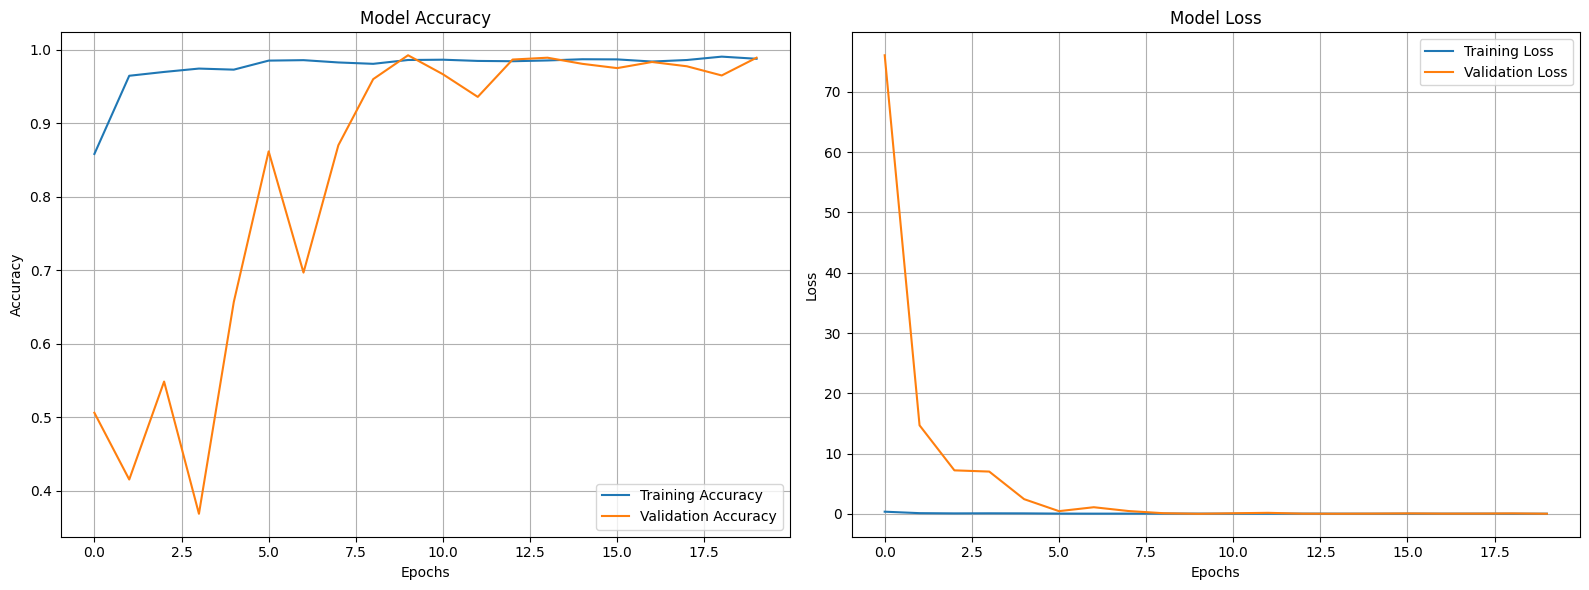

In [87]:
# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Accuracy on the first subplot
ax1.plot(fit.history['accuracy'], label='Training Accuracy')
ax1.plot(fit.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Plot Loss on the second subplot
ax2.plot(fit.history['loss'], label='Training Loss')
ax2.plot(fit.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

<a id="implement-and-test-a-pytorch-based-classifier"></a>

### Implement and Test a PyTorch-Based Classifier

We will need scikit-learn, torchvision, and PyTorch already installed in the setup stage.

#### Import Libraries

In [116]:
%%time
# --- AI LIBRARY IMPORTS ---
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Imported libraries")

Imported libraries
CPU times: total: 15.6 ms
Wall time: 0 ns


#### Ensuring repeatability in PyTorch

To achieve reproducible results when you train a CNN in PyTorch, you must follow three steps:

1.  Define a helper called `set_seed` that seeds every random-number generator and configures cuDNN for deterministic kernels.
2.  Call `set_seed()` *once* at the top of your script/notebook to lock in the seed for the main process.
3.  Provide a `worker_init_fn` so each `DataLoader` worker starts from a reproducible seed as well.


#### Define the `set_seed` function
What the `set_seed` function does

* **Python & NumPy** – Many data-pipeline utilities (shuffling lists, image augmentations) rely on these random-number generators. Seeding them first removes one entire layer of randomness.
* **PyTorch CPU / GPU** – `torch.manual_seed` covers every op executed on the CPU, while `torch.cuda.manual_seed_all` applies the same seed to each GPU stream so that multi-GPU jobs stay in sync.
* **cuDNN flags** – By default cuDNN picks the fastest convolution algorithm, which can vary run-to-run. Setting `deterministic=True` forces repeatable kernels and turning `benchmark` *off* prevents the auto-tuner from replacing those kernels mid-training.


In [95]:

def set_seed(seed: int = 42) -> None:
    """Seed Python, NumPy, and PyTorch (CPU & all GPUs) and
    make cuDNN run in deterministic mode."""
    # ---- Python and NumPy -------------------------------------------
    random.seed(seed)
    np.random.seed(seed)

    # ---- PyTorch (CPU  &  GPU) --------------------------------------
    torch.manual_seed(seed)            
    torch.cuda.manual_seed_all(seed)   

    # ---- cuDNN: force repeatable convolutions -----------------------
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark     = False 

#### Call `set_seed()`

Running the command *before* you build models, create datasets, or start data-loader workers guarantees that every downstream object inherits the same seed.  If you call it later, some layers or tensors may already have been initialised with non-deterministic values, breaking repeatability. Random initialization is useful for the model so that each neuron starts differently, allowing for convergence and effective learning.


In [96]:
SEED = 42
set_seed(SEED)
print(f"Global seed set to {SEED} — main process is now deterministic.")

Global seed set to 42 — main process is now deterministic.


#### Define `worker_init_fn` function

PyTorch offsets each worker’s seed by default, injecting new randomness. For reproducible results, we want workers to start from **fixed** seeds so every data-augmentation decision (flip, crop, colour-jitter) is repeatable across runs. The `worker_init_fn` function re-seeds Python, NumPy, and PyTorch CPU random-number generators inside **each** worker using a simple deterministic formula (`SEED + worker_id`).  The result will be identical batches, identical gradients, and identical model checkpoints, run after run.


In [97]:
def worker_init_fn(worker_id: int) -> None:
    """Re-seed each DataLoader worker so their RNGs don't collide."""
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed) 
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

<a id="defining-hyperparameters-and-device"></a>

#### Defining hyperparameters and device

We have to define the key **hyperparameters** that control the model's training process. Hyperparameters are set by the user to configure the learning algorithm.

- **`img_size`**: The spatial resolution (height and width) to which all images will be resized. This ensures that the input to the neural network is of a consistent size.
- **`batch_size`**: The number of training examples utilized in one iteration (one forward and backward pass). A larger batch size can lead to faster training but requires more memory.
- **`lr` (Learning Rate)**: A crucial hyperparameter that determines the step size at each iteration while moving toward a minimum of the loss function.
- **`epochs`**: The number of times the learning algorithm will work through the entire training dataset.
- **`model_name`**: The name of the model file that will be created after training. This is useful for saving the checkpoint while training.
- **`device`**: This line programmatically checks if a CUDA-enabled GPU is available using `torch.cuda.is_available()`. If a GPU is found, the device is set to `"cuda"` to leverage hardware acceleration. Otherwise, it defaults to the `"cpu"`. This makes the code portable and efficient.


In [98]:
img_size = 64
batch_size = 128
lr = 0.001
epochs = 20
model_name = "ai_capstone_pytorch_state_dict.pth"
num_classes = 2 #number of classes in the dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device used is {device}")


Device used is cpu


<a id="the-data-pipeline"></a>

#### The Data Pipeline
We have downloaded the dataset and fixed the initial random seed for reproducibility. Now, we can start to build the data pipeline to feed data for training the model.
To create the data pipeline for PyTorch, we will:
1. Define transformations
2. Split the dataset for training and validation
3. Create the dataloader to feed the data into the training model


#### 1. Define transformations
Here, we will define a sequence of operations to be applied to the training images. It includes **data augmentation** techniques like `RandomRotation`, `RandomHorizontalFlip`, and `RandomAffine`. Augmentation artificially expands the training dataset by creating modified versions of images, which helps the model generalize better and reduces overfitting. The pipeline also resizes the image, converts it to a PyTorch tensor, and normalizes its pixel values.
This cell constructs the entire pipeline for loading and preparing the image data for the model. It involves defining transformations, splitting the data, and creating data loaders.


##### Create the training transformation pipeline `train_transform` using the `tranforms.Compose` . 
We will use 
- `transforms.Resize` : To resize all input images to a fixed size, useful for input vector with fixed dimensions for model training
- `transforms.RandomRotation`: For geometrical rotation
- `transforms.RandomHorizontalFlip`: For Geometrical horizontal flipping
- `transforms.RandomAffine`: For adjusting to a different point-of-view

Then, convert the image array to a Tensor using `transforms.ToTensor()`.

And finally, normalize the images between [-1,1] using `transforms.Normalize`.


In [99]:
train_transform = transforms.Compose([transforms.Resize((img_size,img_size)),
                                      transforms.RandomRotation(40),
                                      transforms.RandomHorizontalFlip(),
                                      transforms.RandomAffine(0, shear=0.2),
                                      transforms.ToTensor(),
                                      transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
                                     ])


##### Create the validation transformation pipeline `val_transform`.
The validataion dataset is just for validating the preformace of the model and hence, doesn't need to augment the input images. 
So, we may use 
- `transforms.Resize` : To resize all input images to a fixed size
- `transforms.ToTensor()`
-  `transforms.Normalize`


In [100]:
val_transform = transforms.Compose([transforms.Resize((img_size,img_size)),
                                    transforms.ToTensor(),
                                    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
                                   ])


#### 2. Load and Split the Dataset

We have defined the transformation pipelines for the training and validation datasets. 

Next, we will use the `datasets.ImageFolder` utility to load an image dataset from the root directory `dataset_path`. 

This root directory contains the subdirectories where each subdirectory corresponds to a class (e.g., `data/agri`, `data/non_agri`).


In [101]:
full_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)

The next step in the data loading pipeline is to split the image dataset for training and validation. 

We can use `random_split` from `torch.utils.data` class. 

This method allows us to randomly split the input data based on a pre-defined split ratio for the training and validation datasets. 

In this case, we will use 80% (0.8) dataset for training and 20% (0.20) for validation.


In [102]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
val_dataset.dataset.transform = val_transform

#### 3. Create DataLoaders

Now, you can use the `DataLoader` from `torch.utils.data` class to create a dataset generator for lazy loading of the training dataset.
In the input, we define 
- `train_dataset`: The training image dataset
- `batch_size`: The number of images to be loaded in each batch
- `shuffle`: Set to *True* to load images from the dataset in random order
- `num_workers`: Number of parallel processes used to load the images. This is for optimum utilization of your CPU cores to reduce the image I/O bottleneck (set to 0 for Windows issues)
- `worker_init_fn`: For function to decide on data augmentation. The default is with *random seed* for better generalization or *fixed seed* for reproducible results.


In [108]:
train_loader = DataLoader(train_dataset, 
                          batch_size=batch_size,
                          shuffle=True,
                          num_workers=0,
                          worker_init_fn=worker_init_fn
                         )

Next, we will create `val_loader` for the validation dataset

We need to create the validation dataloader `val_loader` for validation of model in each training step. 


In [109]:
val_loader = DataLoader(val_dataset,
                        batch_size=batch_size,
                        shuffle=False,
                        num_workers=0,
                        worker_init_fn=worker_init_fn)


- **`train_transform`**: This defines a sequence of operations to be applied to the training images. It includes **data augmentation** techniques like `RandomRotation`, `RandomHorizontalFlip`, and `RandomAffine`. Augmentation artificially expands the training dataset by creating modified versions of images, which helps the model generalize better and reduces overfitting. The pipeline also resizes the image, converts it to a PyTorch tensor, and normalizes its pixel values.
- **`val_transform`**: The transformation for the validation set is simpler. It omits the random augmentation steps because you want to evaluate the model's performance on the original, unaltered data.
- **`datasets.ImageFolder`**: This PyTorch utility automatically loads an image dataset from a directory where subdirectories are named after their corresponding classes (e.g., `data/agri`, `data/non_agri`).
- **`random_split`**: The full dataset is partitioned into training (80%) and validation (20%) sets. This separation is crucial for assessing how well the model generalizes to unseen data.
- **`DataLoader`**: These objects wrap the datasets and provide an efficient, iterable way to feed data to the model in batches. `shuffle=True` for the `train_loader` ensures that the model sees the data in a different order each epoch, which helps prevent it from learning the order of the training examples. `worker_init_fn` ensures that **fixed seed** is passed to the `dataloader` for reproducibility.


<a id="defining-the-model"></a>

#### Defining the model

We will define the Convolutional Neural Network (CNN) architecture and configure the components needed for training.
<p></p>


<p></p>

- **`model = nn.Sequential(...)`**: A sequential container is used to build the model as a linear stack of layers. This is a convenient way to define a straightforward CNN.
  - **Convolutional Blocks**: The model consists of several blocks, each containing
      - a `Conv2d` layer for feature extraction,
      - a `ReLU` activation function,
      - a `MaxPool2d` layer to downsample and reduce dimensionality,
      - a`BatchNorm2d` to stabilize and accelerate training.    
  - **Classifier**: After the convolutional blocks,
      - `AdaptiveAvgPool2d` reduces each feature map to a single value, making the model more robust to input size variations.
      - `Flatten` converts the 2D feature maps into a 1D vector.
      - `Linear` (fully connected) layers then perform the final classification,
      - `Dropout` is used as a regularization technique to prevent overfitting.
  - **`.to(device)`**: This moves the model's parameters and buffers to the selected device (GPU, if available otherwise CPU).


In [110]:
# --- MODEL ---
model = nn.Sequential(
                        # Conv Block 1
                        nn.Conv2d(3, 32, 5, padding=2), nn.ReLU(),
                        nn.MaxPool2d(2), nn.BatchNorm2d(32),
                        
                        # Conv Block 2-6
                        nn.Conv2d(32, 64, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(64),
                        nn.Conv2d(64, 128, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(128),
                        nn.Conv2d(128, 256, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(256),
                        nn.Conv2d(256, 512, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(512),
                        nn.Conv2d(512, 1024, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(1024),
                        
                        # Classifier
                        nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                        nn.Linear(1024, 2048), nn.ReLU(), nn.BatchNorm1d(2048), nn.Dropout(0.4),
                        nn.Linear(2048, num_classes)
                    ).to(device)

#### Defining the training setup

After defining the model, we declare the loss function and the optimizer for backpropagation and learning.
We also set up the tracking of the history of the model training for loss and accuracy for every step of the model training



- The loss function is defined using **`criterion = nn.CrossEntropyLoss()`**
    - `CrossEntropyLoss` is specifically designed for multi classs classification problems.
<p></p>
<p></p> 

- The optimizer is defined using **`optimizer = optim.Adam(...)`**:
    - The Adam optimizer is chosen to update the model's weights. It's an adaptive learning rate method that is computationally efficient and works well in practice.
<p></p>

<p></p>
 
- We can **track the history** using `best_loss`, `loss_history` and `acc_history` dictionaries
    - `best_loss`: stores the best validation loss achieved so far.
    - `loss_history` and `acc_history` dictionaries to log the loss and accuracy history for plotting later.


In [111]:
# --- TRAINING SETUP ---
#criterion = nn.BCEWithLogitsLoss()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
best_loss = float('inf')
loss_history = {'train': [], 'val': []}
acc_history = {'train': [], 'val': []}

<a id="training-and-validation"></a>

#### Training and validation

Our neural network is now ready for training.

Here, we will set up the main logic for how the model learns from the data. The model iterates through the dataset for the specified number of epochs, with each epoch consisting of a training phase and a validation phase.

- **Outer Loop (`for epoch in range(epochs)`)**: Controls the number of full passes over the dataset.

<p></p>

<p></p>
 

- **We will be training the model for 20 epochs**.

<p></p>

<p></p>
 
- **Training Phase**:
  - `model.train()`: Sets the model to training mode. This activates layers like Dropout and ensures BatchNorm layers learn from the current batch statistics.
  - **Inner Loop (`for images, labels in train_loader`)**: Iterates over batches of training data.
  - `optimizer.zero_grad()`: Clears the gradients from the previous iteration before computing new ones.
  - `outputs = model(images)`: **Forward Pass**. The input data is passed through the network to get predictions (logits).
  - `loss.backward()`: **Backward Pass**. Gradients of the loss with respect to the model's parameters are calculated.
  - `optimizer.step()`: The optimizer updates the model's parameters using the computed gradients.

<p></p>

<p></p>
 
- **Validation Phase**:
  - `model.eval()`: Sets the model to evaluation mode. This deactivates Dropout and makes BatchNorm layers use their learned running statistics.
  - `with torch.no_grad()`: Disables gradient calculation, which speeds up computation and reduces memory usage since you are only evaluating, not training.

<p></p>

<p></p>
 
- **Model Checkpointing**: After each epoch, the current validation loss is compared to the `best_loss` seen so far. If the current loss is lower, the model's state (`model.state_dict()`) is saved to a file. This ensures that you keep the model version that performed best on the validation set.


In [112]:
print(f"Training on : ==={device}=== with batch size: {batch_size} & lr: {lr}")

# --- TRAINING LOOP ---
for epoch in range(epochs):
    # Training Phase
    start_time = time.time() # to get the training time for each epoch
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0  # for the training metrics
    for batch_idx, (images, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")):
        images, labels = images.to(device), labels.to(device)  # labels as integer class indices
        optimizer.zero_grad()
        outputs = model(images)  # outputs are raw logits
        loss = criterion(outputs, labels)  # criterion is nn.CrossEntropyLoss
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
  
    # Synchronize CUDA before stopping timer (if using GPU)
    if device == 'cuda':
        torch.cuda.synchronize()

    # Validation Phase
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0 #  for the validation metrics
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
  
    # Save the best model
    avg_val_loss = val_loss/len(val_loader)
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save(model.state_dict(), model_name)
    
    # Store metrics
    loss_history['train'].append(train_loss/len(train_loader))
    loss_history['val'].append(val_loss/len(val_loader))
    acc_history['train'].append(train_correct/train_total)
    acc_history['val'].append(val_correct/val_total)
    
    #print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {loss_history['train'][-1]:.4f} | Val Loss: {loss_history['val'][-1]:.4f}")
    print(f"Train Acc: {acc_history['train'][-1]:.4f} | Val Acc: {acc_history['val'][-1]:.4f}")
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1} training completed in {epoch_time:.2f} seconds\n") 

print("Model Training Complete!")

Training on : ===cpu=== with batch size: 128 & lr: 0.001


Epoch 1/20: 100%|██████████| 38/38 [00:10<00:00,  3.71it/s]


Train Loss: 0.2300 | Val Loss: 0.0358
Train Acc: 0.9419 | Val Acc: 0.9883
Epoch 1 training completed in 11.83 seconds



Epoch 2/20: 100%|██████████| 38/38 [00:10<00:00,  3.72it/s]


Train Loss: 0.0181 | Val Loss: 0.0095
Train Acc: 0.9942 | Val Acc: 0.9942
Epoch 2 training completed in 11.38 seconds



...

Train Loss: 0.0124 | Val Loss: 0.0111
Train Acc: 0.9954 | Val Acc: 0.9967
Epoch 18 training completed in 11.58 seconds



Epoch 19/20: 100%|██████████| 38/38 [00:10<00:00,  3.56it/s]


Train Loss: 0.0064 | Val Loss: 0.0037
Train Acc: 0.9977 | Val Acc: 0.9983
Epoch 19 training completed in 11.72 seconds



Epoch 20/20: 100%|██████████| 38/38 [00:09<00:00,  3.85it/s]


Train Loss: 0.0046 | Val Loss: 0.0379
Train Acc: 0.9985 | Val Acc: 0.9883
Epoch 20 training completed in 10.93 seconds

Model Training Complete!


<a id="visualizing-training-history"></a>

#### Visualizing training history

Here, we can use `matplotlib` to create plots of the model's accuracy and loss over each epoch. Visualizing these metrics is useful for understanding the training dynamics.


Usually, the following two plots are used to track the training history of a model:
- **Accuracy Plot**: Shows the training accuracy versus the validation accuracy. A large gap between the two curves can be an indicator of overfitting, where the model performs well on the data it has seen but poorly on new, unseen data.

- **Loss Plot**: Shows the training loss versus the validation loss. An ideal plot shows both losses decreasing and converging. If the validation loss starts to increase while the training loss continues to decrease, it's a strong sign of overfitting.

 
These plots provide an intuitive, visual summary of the entire training process and help diagnose potential issues or confirm that the model has trained successfully.


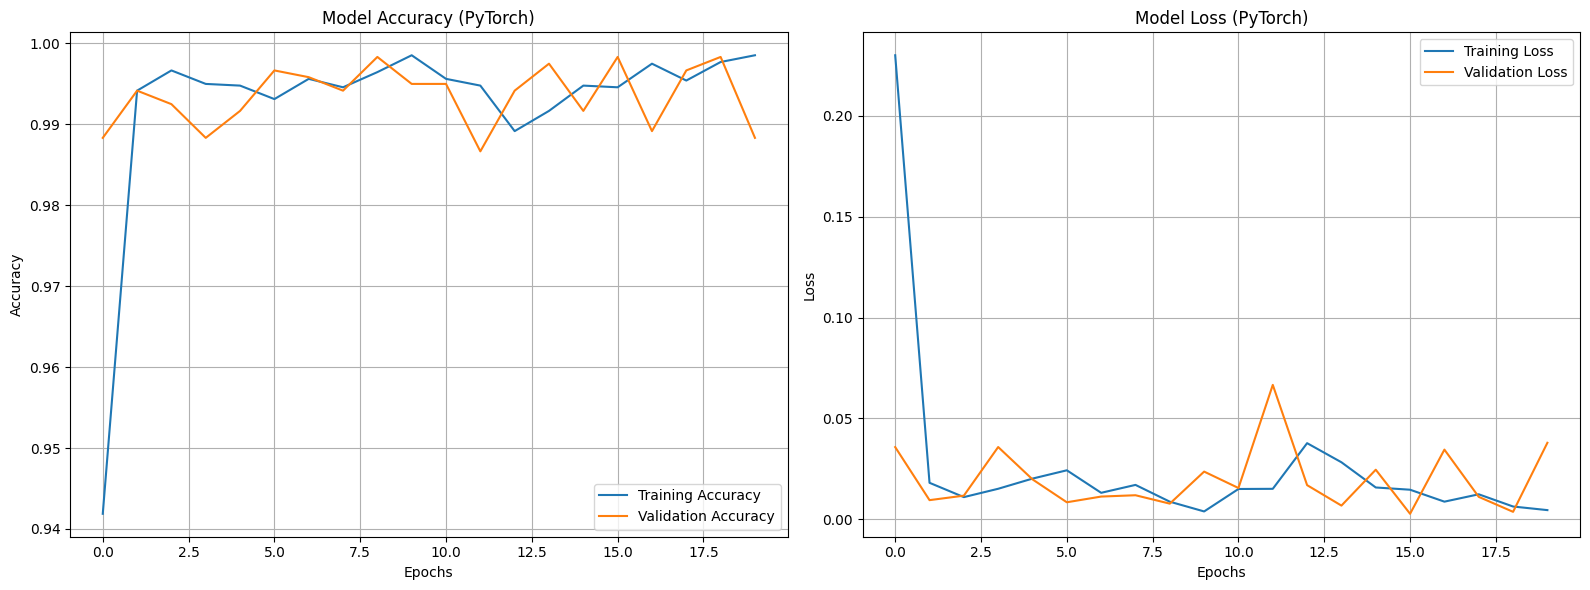

In [113]:
# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Accuracy on the first subplot
ax1.plot(acc_history['train'], label='Training Accuracy')
ax1.plot(acc_history['val'], label='Validation Accuracy')
ax1.set_title('Model Accuracy (PyTorch)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Plot Loss on the second subplot
ax2.plot(loss_history['train'], label='Training Loss')
ax2.plot(loss_history['val'], label='Validation Loss')
ax2.set_title('Model Loss (PyTorch)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

#### Final model evaluation

This cell comprehensively evaluates the best-performing model saved during the training loop. While accuracy provides a high-level view, these metrics provide a deeper insight into the model's behavior.


- **`model.eval()`**: Switches the model to evaluation mode.
- **`with torch.no_grad()`**: Disables gradient computation for efficiency.
- **Collecting Predictions**: The code iterates through the entire validation set to gather all predictions and their corresponding true labels.

- **`accuracy`**: The proportion of correct predictions out of the total predictions.


To evaluate the model, we have to get the predictions for the images.


For the images from `val_loader`, get a list of :
<p></p>  

<p></p>  
 
**1.** all predictions `all_preds`

**2.** the ground truth labels `all_labels` 

For the predictions, we will have to move the data to the CPU using `predictions.cpu()`


In [114]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(labels.numpy())



<a id="get-the-accuracy-of-the-model"></a>

#### Get the accuracy of the model

**`accuracy`** is the proportion of correct predictions out of the total predictions.

We can use `accuracy_score` from `sklearn.metrics` class to calculate the **accuracy_score**


In [115]:
accuracy = accuracy_score(all_labels, all_preds)
print(f"The accuracy of the model is: {accuracy:.4f}")

The accuracy of the model is: 0.9883


<a id="comparative-analysis-of-keras-and-pytorch-models"></a>

### Comparative Analysis of Keras and PyTorch Models

<a id="evaluation-metrics"></a>

#### Evaluation metrics 

The following metrics are used for evaluation of various AI/ML models:
    
- Accuracy
- Precision
- Recall
- F1 score
- Confusion matrix
- Receiver Operating Characteristic - Area Under Curve (ROC-AUC)

Their calculation methods and their significance for model performance are below.


##### 1. Accuracy

**Definition:**
Accuracy is the proportion of correct predictions (both true positives and true negatives) among the total number of cases examined. In other words, it measures how often the classifier is correct overall.

**Formula:**
\[
Accuracy = $\frac{TP + TN}{TP + TN + FP + FN}$
\]

- TP: True positives (correctly predicted positive cases)
- TN: True negatives (correctly predicted negative cases)
- FP: False positives (incorrectly predicted positive cases)
- FN: False negatives (incorrectly predicted negative cases)

**Significance:**

Accuracy is intuitive and easy to interpret, making it a common first metric for model evaluation. However, it can be misleading if the dataset is imbalanced (i.e., one class is much more frequent than the other). This is because a model can achieve high accuracy by simply predicting the majority class.


##### 2. Precision

**Definition:**
Precision measures the proportion of positive predictions that are actually correct. It answers the question: "Of all the samples that the model predicted as positive, how many were truly positive?"

**Formula:**
\[
Precision = $\frac{TP}{TP + FP}$
\]

**Significance:**
Precision is crucial when the cost of a false positive is high. For example, in medical diagnosis, predicting a disease when it's not present (false positive) can lead to unnecessary treatments. In land classification, high precision means that when the model predicts a tile as agricultural, it is likely correct.


##### 3. Recall (sensitivity or true positive rate)

**Definition:**
Recall measures the proportion of actual positive cases that were correctly identified by the model. It answers: "Of all the true positive samples, how many did the model identify?"

**Formula:**
\[
Recall = $\frac{TP}{TP + FN}$
\]

**Significance:**
Recall is important when the cost of missing a positive case (false negative) is high. In land classification, high recall means the model is good at finding all the agricultural land, even if it sometimes mislabels non-agricultural land as agricultural.


##### 4. F1 score

**Definition:**
The F1 score is the harmonic mean of precision and recall. It provides a single metric that balances both concerns. It is especially useful when you need to find an equilibrium between precision and recall.

**Formula:**
\[
F1 = $2 \times \frac{Precision \times Recall}{Precision + Recall}$
\]

**Significance:**
The F1 score is especially valuable when the class distribution is uneven or when both false positives and false negatives are important. It penalizes extreme values, so a model with high precision but low recall (or vice versa) will have a lower F1 score.


##### 5. Confusion matrix

**Definition:**
A confusion matrix is a table that summarizes the performance of a classification algorithm. It displays the counts of true positives, false positives, true negatives, and false negatives.

|               | Predicted positive | Predicted negative |
|---------------|-------------------|-------------------|
| Actual positive | True positive (TP) | False negative (FN) |
| Actual negative | False positive (FP) | True negative (TN) |

**Significance:**
The confusion matrix provides a detailed breakdown of model errors and successes, helping you understand not just how often the model is right, but *how* it is wrong. This is crucial for diagnosing issues like class imbalance or systematic misclassification.


##### 6. ROC-AUC (Receiver operating characteristic - Area under curve)

**Definition:**
ROC-AUC measures the model's ability to distinguish between classes across all possible classification thresholds. The ROC curve plots the true positive rate (recall) against the false positive rate at various thresholds. The AUC (area under the curve) summarizes this performance in a single value between 0 and 1.

**Significance:**
A model with an ROC-AUC of 1.0 perfectly distinguishes between classes, while a value of 0.5 suggests random guessing. ROC-AUC is especially useful for imbalanced datasets and when you care about the ranking of predictions rather than their absolute values.


#### Import the evaluation metrics

Here we define the functions to compute and print classification metrics including accuracy, precision, recall, F1 score, ROC-AUC, confusion matrix, and log loss. These functions support both Keras and PyTorch model outputs.


In [120]:
%%time 

from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             roc_curve, 
                             roc_auc_score,
                             log_loss,
                             classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay,
                            )
from sklearn.preprocessing import label_binarize

# define a function to get the metrics comprehensively
def model_metrics(y_true, y_pred, y_prob, class_labels):
    metrics = {'Accuracy': accuracy_score(y_true, y_pred),
               'Precision': precision_score(y_true, y_pred),
               'Recall': recall_score(y_true, y_pred),
               'Loss': log_loss(y_true, y_prob),
               'F1 Score': f1_score(y_true, y_pred),
               'ROC-AUC': roc_auc_score(y_true, y_prob),
               'Confusion Matrix': confusion_matrix(y_true, y_pred),
               'Classification Report': classification_report(y_true, y_pred, target_names=class_labels, digits=4),
               "Class labels": class_labels
              }
    return metrics

#function to print the metrics
def print_metrics(y_true, y_pred, y_prob, class_labels, model_name):
    metrics = model_metrics(y_true, y_pred, y_prob, class_labels)
    print(f"Evaluation metrics for the {model_name}")
    print(f"Accuracy: {'':<1}{metrics['Accuracy']:.4f}")
    print(f"ROC-AUC: {'':<2}{metrics['ROC-AUC']:.4f}")
    print(f"Loss: {'':<5}{metrics['Loss']:.4f}\n")
    print(f"Classification report:\n\n  {metrics['Classification Report']}")
    print("========= Confusion Matrix =========")
    disp = ConfusionMatrixDisplay(confusion_matrix=metrics["Confusion Matrix"],
                                  display_labels=metrics["Class labels"])

    disp.plot()
    plt.show()

CPU times: total: 0 ns
Wall time: 0 ns


#### Model Paths

In the cell below, we define the file paths for the previously saved Keras and PyTorch models.


In [121]:
data_dir = "."

keras_model_name = "ai_capstone_keras_best_model.model.keras"
keras_model_path = os.path.join(data_dir, keras_model_name)

pytorch_state_dict_name = "ai_capstone_pytorch_state_dict.pth"
pytorch_state_dict_path = os.path.join(data_dir, pytorch_state_dict_name)

print(f"keras_model_path: {os.path.exists(keras_model_path)} ___ {keras_model_path}")
print(f"pytorch_state_dict_path: {os.path.exists(pytorch_state_dict_path)} ___ {pytorch_state_dict_path}")

keras_model_path: True ___ .\ai_capstone_keras_best_model.model.keras
pytorch_state_dict_path: True ___ .\ai_capstone_pytorch_state_dict.pth


#### Dataset path and parameters

Here, for downstream processing, we define 
1. the dataset directory path
2. define image dimensions
3. number of channels
4. batch size
5. number of classes
6. class labels


In [122]:
dataset_path = os.path.join(data_dir, "images_dataSAT")
print(dataset_path)

img_w, img_h = 64, 64
n_channels = 3
batch_size = 128
num_classes = 2

agri_class_labels = ["non-agri", "agri"]


.\images_dataSAT


<a id="keras-model-evaluation-and-prediction"></a>

#### Keras model evaluation and prediction

In this cell, we will:
- Use `ImageDataGenerator` to rescale images.
- Load test images from the dataset directory.
- Load the saved Keras model using `tf.keras.models.load_model`.
- Run predictions on the test set, collect predicted probabilities, predicted classes, and true labels.


In [123]:
%%time

datagen = ImageDataGenerator(rescale=1./255)
prediction_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_w, img_h),
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

keras_model = tf.keras.models.load_model(keras_model_path)

steps = int(np.ceil(prediction_generator.samples / prediction_generator.batch_size))
batch_size = int(prediction_generator.batch_size)
print(f"Number of Steps: {steps} with batch size: {batch_size}")

all_preds_keras = []
all_probs_keras = []
all_labels_keras = []

for step_idx, step in enumerate(tqdm(range(steps), desc="Steps")):
    images, labels = next(prediction_generator)
    preds = keras_model.predict(images, verbose='0')
    all_probs_keras.extend(preds)
    preds = (preds > 0.5).astype(int).flatten()
    all_preds_keras.extend(preds)
    all_labels_keras.extend(labels)

Found 6000 images belonging to 2 classes.
Number of Steps: 47 with batch size: 128


Steps: 100%|██████████| 47/47 [00:06<00:00,  7.51it/s]

CPU times: total: 20.1 s
Wall time: 6.9 s


<a id="keras-metrics-reporting"></a>

#### Keras metrics reporting


Print various performance metrics for the **Keras** model. We will use the previously defined metrics print function `print_metrics`.


Evaluation metrics for the Keras Model
Accuracy:  0.9942
ROC-AUC:   1.0000
Loss:      0.0174

Classification report:

                precision    recall  f1-score   support

    non-agri     0.9885    1.0000    0.9942      3000
        agri     1.0000    0.9883    0.9941      3000

    accuracy                         0.9942      6000
   macro avg     0.9942    0.9942    0.9942      6000
weighted avg     0.9942    0.9942    0.9942      6000

========= Confusion Matrix =========


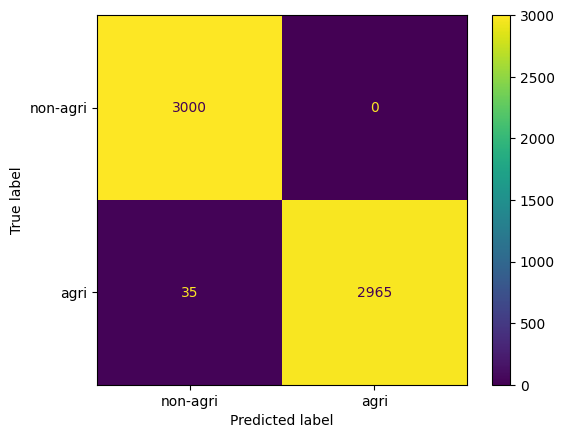

In [124]:
## Please use the space below to write your answer
print_metrics(y_true = all_labels_keras,
              y_pred = all_preds_keras,
              y_prob = all_probs_keras,
              class_labels = agri_class_labels,
              model_name = "Keras Model")


<a id="pytorch-model-evaluation-and-prediction"></a>

#### PyTorch model evaluation and prediction

In this cell, we:
- Set device for inference (GPU if available).
- Define data transformations including resizing, normalization.
- Load the dataset using `ImageFolder` and prepares a DataLoader.
- Define the CNN architecture matching the saved state dict.
- Load model weights.
- Run inference on the test set, collecting predicted classes, probabilities, and true labels for metric calculation.


In [125]:
%%time
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Processing inference on {device}")

train_transform = transforms.Compose([
    transforms.Resize((img_w, img_h)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
full_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)
test_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False)

model = nn.Sequential(
    nn.Conv2d(3, 32, 5, padding=2), nn.ReLU(),
    nn.MaxPool2d(2), nn.BatchNorm2d(32),
    nn.Conv2d(32, 64, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(64),
    nn.Conv2d(64, 128, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(128),
    nn.Conv2d(128, 256, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(256),
    nn.Conv2d(256, 512, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(512),
    nn.Conv2d(512, 1024, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(1024),
    nn.AdaptiveAvgPool2d(1), nn.Flatten(),
    nn.Linear(1024, 2048), nn.ReLU(), nn.BatchNorm1d(2048), nn.Dropout(0.4),
    nn.Linear(2048, num_classes)
).to(device)

print("Created model, now loading the weights from saved model state dict")
model.load_state_dict(torch.load(pytorch_state_dict_path))
print("Loaded model state dict, now getting predictions")

all_preds_pytorch = []
all_labels_pytorch = []
all_probs_pytorch = []


model.eval()
with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(tqdm(test_loader, desc="Step")):
#    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        probs = F.softmax(outputs, dim=1)[:, 1]  # probability for class 1
        all_probs_pytorch.extend(probs.cpu())
        all_preds_pytorch.extend(preds.cpu().numpy().flatten())
        all_labels_pytorch.extend(labels.numpy())

Processing inference on cpu
Created model, now loading the weights from saved model state dict
Loaded model state dict, now getting predictions


Step: 100%|██████████| 47/47 [00:05<00:00,  8.97it/s]

CPU times: total: 34.3 s
Wall time: 5.32 s


<a id="pytorch-metrics-reporting"></a>

#### PyTorch metrics reporting


Print various performance metrics for the **PyTorch** model. We will use the previously defined metrics print function `print_metrics`.


Evaluation metrics for the PyTorch Model
Accuracy:  0.9995
ROC-AUC:   1.0000
Loss:      0.0015

Classification report:

                precision    recall  f1-score   support

    non-agri     0.9990    1.0000    0.9995      3000
        agri     1.0000    0.9990    0.9995      3000

    accuracy                         0.9995      6000
   macro avg     0.9995    0.9995    0.9995      6000
weighted avg     0.9995    0.9995    0.9995      6000

========= Confusion Matrix =========


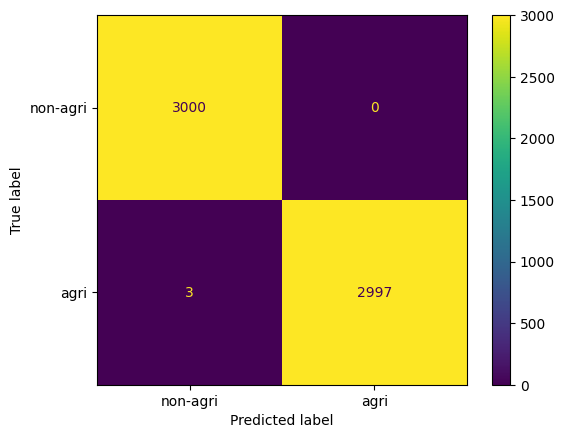

In [126]:
## Please use the space below to write your answer
print_metrics(y_true = all_labels_pytorch,
              y_pred = all_preds_pytorch,
              y_prob = all_probs_pytorch,
              class_labels = agri_class_labels,
              model_name = "PyTorch Model")


<a id="roc-curve-plotting"></a>

#### ROC curve plotting

First, we define a function to plot ROC curves for binary or multi-class classification using scikit-learn's `roc_curve` and `roc_auc_score`. It handles both single-class and multi-class cases by binarizing labels if needed.


In [127]:

def plot_roc(y_true, y_prob, model_name):
    n_classes = y_prob.shape[1] if y_prob.ndim > 1 else 1
    if n_classes == 1:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.2f})')
    else:
        y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
            auc = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
            plt.plot(fpr, tpr, label=f'{model_name} class {i} (AUC = {auc:.2f})')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()

Next, we plot the ROC curves for both Keras and PyTorch models on the same figure for visual performance comparison.


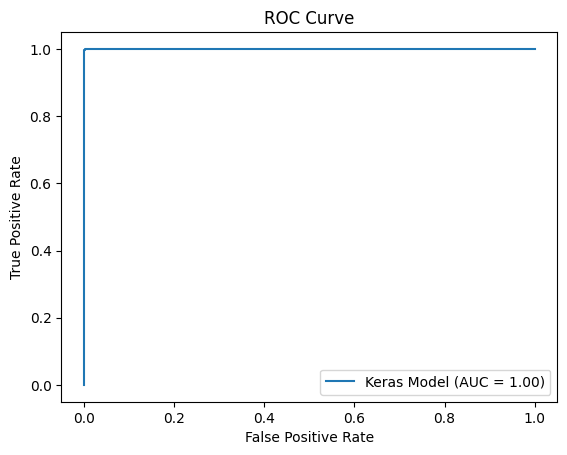

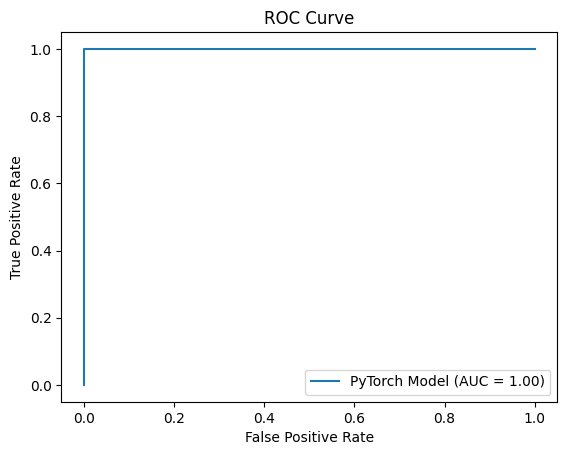

In [128]:
plot_roc(np.array(all_labels_keras), np.array(all_probs_keras), "Keras Model")
plt.show()
plot_roc(np.array(all_labels_pytorch), np.array(all_probs_pytorch), "PyTorch Model")
plt.show()

<a id="comparing-model-performance"></a>

#### Comparing model performance

Now let's compare the performance of different models to understand which model would be the best performer for our land classification task.


In [130]:
# get the Keras model performance metrics
metrics_keras = model_metrics(all_labels_keras, all_preds_keras, all_probs_keras, agri_class_labels)

# get the PyTorch model performance metrics
metrics_pytorch = model_metrics(all_labels_pytorch, all_preds_pytorch, all_probs_pytorch, agri_class_labels)


# Display the comparison of metrics
print("{:<18} {:<15} {:<15}".format('\033[1m'+ 'Metric' + '\033[0m',
                                    'Keras Model', 
                                    'PyTorch Model'))

mertics_list = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

for k in mertics_list:
    print("{:<18} {:<15.4f} {:<15.4f}".format('\033[1m'+k+'\033[0m',
                                              metrics_keras[k],
                                              metrics_pytorch[k]))

Metric     Keras Model     PyTorch Model  
Accuracy   0.9942          0.9995         
Precision  1.0000          1.0000         
Recall     0.9883          0.9990         
F1 Score   0.9941          0.9995         
ROC-AUC    1.0000          1.0000         


<a id="metric-analysis"></a>

#### Metric analysis

The metrics for the pre-trained Keras and PyTorch models for evaluating the provided dataset are:

- **Accuracy**
    1. Keras: 0.9942
    2. PyTorch: 0.9995
    
    ===> Both models achieve exceptional accuracy, but the **PyTorch model makes fewer mistakes**.

- **Precision**
    1. Keras: 1.0000
    2. PyTorch: 1.000

    ===> Both models perfectly **avoid false positives**.

- **Recall**
    1. Keras: 0.9883
    2. PyTorch: 0.9990
    
    ===> The **PyTorch** model is marginally better at **identifying all true positives**, capturing nearly all actual positive cases, while the Keras model misses a few.

- **F1 Score**
    1. Keras: 0.9941
    2. PyTorch: 0.9995
    
    ===> The F1 score, which balances precision and recall, favors the **PyTorch** model thanks to its **stronger recall**.

- **ROC-AUC**
    1. Keras: 1.0000
    2. PyTorch: 1.0000
    
    ===> Both models reach maximum possible **discrimination between classes**, indicating outstanding capability for binary classification.


<a id="model-comparison-key-insights"></a>

#### **Model comparison: Key insights**


**PyTorch model strengths**

 - Achieves the highest scores in accuracy, recall, and F1, indicating extremely robust overall performance and near-perfect classification of positive cases
- ROC-AUC of 1.0 shows perfect class separability


**Keras model strengths**

- Displays almost perfect precision, every positive prediction made is correct
- Also achieves perfect ROC-AUC, indicating outstanding discrimination ability


**Common strength**

- Both models deliver flawless ROC-AUC, suggesting both are highly effective for this classification task


**Recommendations**

Based on the scores from the models:

- The PyTorch model is preferable for applications where missing any positive instances is costly (higher recall)
- The Keras model is optimal for scenarios where making any false positive error is unacceptable (higher precision).


**Next**

- Analyze the confusion matrices to investigate the errors.
- Monitor real-world performance, as even marginal differences can become important in high-impact applications. 


**Summary**

Both models excel in all evaluated metrics and would be highly reliable in production. The PyTorch model demonstrates a modest edge in recall and F1 score, while the Keras model maximizes precision. The choice between models should ultimately reflect the specific requirements and risk tolerance of your use case.



<a id="part-3---cnn---vision-transformer-integration"></a>

## Part 3 - CNN - Vision Transformer Integration

At this point we have built a CNN to successfully identify agricultural land. Now, we will use our CNN to build a CNN-Vision Transformer (ViT) hybrid image classification model. We will start by loading our existing CNN that is good at recognizing small patterns in pictures. Then, we will improve it with a transformer, which helps the model see and use wider and more complex relationships in an image. We will cover preparing our image data, making our model smarter with both local and global learning, and saving our best results automatically.


<a id="vision-transformers-in-keras"></a>

### Vision Transformers in Keras

First, make sure our directories and random seeds are set.

In [133]:
data_dir = "."

keras_model_name = "ai_capstone_keras_best_model.model.keras"
keras_model_path = os.path.join(data_dir, keras_model_name)
print(f"keras_model_path: {os.path.exists(keras_model_path)} ___ {keras_model_path}")

# Set seed for reproducibility
seed_value = 7331
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
print(f"Random seeds set")

keras_model_path: True ___ .\ai_capstone_keras_best_model.model.keras
Random seeds set


#### Model loading and setup

Here, we will load our previously-trained CNN model and learn to work with saved Keras models and prepare them for use in the hybrid architecture.


Let's load the CNN model in `cnn_model` variable using `load_model()` function and print model summary using `summary()` method.

The `load_model()` function loads the complete Keras model, including architecture, weights, and compilation state. The loaded model serves as the CNN backbone for feature extraction in the hybrid architecture. The `cnn_model.summary()` line can be uncommented to inspect the model architecture and identify appropriate layers for feature extraction.


In [136]:
cnn_model = load_model(keras_model_path)
cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 512)      │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 2, 2, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 2, 2, 1024)     │    13,108,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 1, 1, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 1, 1, 1024)     │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │             

 Total params: 61,034,501 (232.83 MB)

 Trainable params: 20,340,801 (77.59 MB)

 Non-trainable params: 12,096 (47.25 KB)

 Optimizer params: 40,681,604 (155.19 MB)

Based on our `model.summary()` above, we can get the name of the layer from the CNN model for feature extraction in the variable `feature_layer_name`.

This is the last convolutional layer, right before `GlobalAveragePooling2D`.


In [137]:
feature_layer_name = "batch_normalization_25"


<a id="custom-positional-embedding-layer"></a>

#### Custom positional embedding layer

In this cell, we define a custom Keras layer called `AddPositionEmbedding` that implements positional embeddings for the Vision Transformer architecture. Positional embeddings are crucial in transformer models because they lack inherent spatial awareness, unlike convolutional layers that have built-in spatial inductive biases.

- The class inherits from `layers.Layer`, making it a proper Keras custom layer
- In the `__init__` method, it creates a trainable weight matrix using `self.add_weight()`
- The positional embedding has shape `(1, num_patches, embed_dim)` where the first dimension allows broadcasting across batch sizes
- The `initializer="random_normal"` ensures the embeddings start with random values that will be learned during training
- The `trainable=True` parameter makes these embeddings learnable parameters


This layer is essential for the hybrid CNN-ViT architecture because when CNN feature maps are flattened into tokens, spatial relationships are lost. The positional embeddings restore spatial awareness by providing each token with information about its original spatial location in the feature map. This allows the transformer to understand which tokens are spatially adjacent or distant, enabling it to make spatially aware attention decisions.

The `call` method adds the positional embeddings to the input tokens using element-wise addition. This is computationally efficient and follows the standard transformer approach, where positional information is added to preserve the embedding dimension.


In [138]:
# Positional embedding that Keras can track
@tf.keras.utils.register_keras_serializable(package="Custom")
class AddPositionEmbedding(layers.Layer):
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.embed_dim   = embed_dim
        self.pos = self.add_weight(
            name="pos_embedding",
            shape=(1, num_patches, embed_dim),
            initializer="random_normal",
            trainable=True)

    def call(self, tokens):
        return tokens + self.pos

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "embed_dim":   self.embed_dim,
        })
        return {**config}

<a id="transformer-block-implementation"></a>

#### Transformer block implementation

In this code cell, we will implement a complete transformer encoder block, the fundamental building block of the Vision Transformer architecture. The `TransformerBlock` class encapsulates the standard transformer encoder architecture with multi-head self-attention and feed-forward neural network components.

**Role in hybrid architecture:**
In the CNN-ViT hybrid, these transformer blocks process the tokenized CNN feature maps, allowing the model to capture long-range spatial dependencies that CNNs might miss due to their limited receptive fields. The self-attention mechanism enables each spatial location to attend to all other locations, providing global context awareness.

**Technical architecture:**
- **Multi-head attention (MHA):** Uses `layers.MultiHeadAttention` with a configurable number of heads and key dimension equal to embed_dim
- **Layer normalization:** Two `LayerNormalization` layers with epsilon=1e-6 for numerical stability
- **MLP block:** A two-layer feed-forward network with GELU activation and dropout for regularization
- **Residual connections:** Implements skip connections around both the attention and MLP blocks

**Parameters:**
- `embed_dim`: The dimensionality of token embeddings (typically matches CNN feature map channels)
- `num_heads`: Number of attention heads (default 8, must divide embed_dim evenly)
- `mlp_dim`: Hidden dimension of the MLP block (typically 4x embed_dim)
- `dropout`: Dropout rate for regularization (default 0.1)

**Forward pass logic:**
Forward pass allows the model to capture both local and global dependencies in the feature representations while maintaining gradient flow through residual connections.


In [139]:
# One Transformer encoder block
@tf.keras.utils.register_keras_serializable(package="Custom")
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads=8, mlp_dim=2048, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.mlp_dim   = mlp_dim
        self.dropout   = dropout
        self.mha  = layers.MultiHeadAttention(num_heads, key_dim=embed_dim)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = tf.keras.Sequential([
            layers.Dense(mlp_dim, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(embed_dim),
            layers.Dropout(dropout)
        ])

    def call(self, x):
        x = self.norm1(x + self.mha(x, x))
        return self.norm2(x + self.mlp(x))

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim":  self.embed_dim,
            "num_heads":  self.num_heads,
            "mlp_dim":    self.mlp_dim,
            "dropout":    self.dropout,
        })
        return {**config}


<a id="hybrid-model-builder-function"></a>

#### Hybrid model builder function

Now, we will define a function `build_cnn_vit_hybrid` that constructs the complete hybrid CNN-Vision Transformer model. This function represents the main architectural innovation of the notebook, combining the strengths of convolutional neural networks for local feature extraction with transformers for global context modeling.

**Function architecture:**
1. **CNN feature extraction:** Extracts intermediate feature maps from a pre-trained CNN at a specified layer
2. **Tokenization:** Reshapes spatial feature maps into a sequence of tokens suitable for transformer processing
3. **Positional encoding:** Adds learnable positional embeddings to maintain spatial relationships
4. **Transformer stack:** Applies multiple transformer encoder blocks for global context modeling
5. **Classification head:** Pools tokens and applies the final classification layer

**Parameters:**
- `cnn_model`: Pre-trained CNN model for feature extraction
- `feature_layer_name`: Name of the CNN layer to extract features from (e.g., `batch_normalization_25` in the original model architecture)
- `num_transformer_layers`: Number of transformer blocks to stack (default 4)
- `num_heads`: Number of attention heads per transformer block (default 8)
- `mlp_dim`: MLP hidden dimension in transformer blocks (default 2048)
- `num_classes`: Number of output classes for classification

The function first freezes the CNN backbone (`cnn_model.trainable = False`) to use it as a fixed feature extractor. It then extracts feature maps with shape (B, H, W, C) and reshapes them to (B, H*W, C), where each spatial location becomes a token. The `AddPositionEmbedding` layer adds spatial awareness, and multiple TransformerBlock layers process the tokens. Finally, `GlobalAveragePooling1D` aggregates all tokens, and a dense layer with softmax activation produces class predictions.

This hybrid approach leverages CNN's local feature detection capabilities while adding the transformer's global attention mechanism. The result is a model that can capture both fine-grained local patterns and long-range spatial dependencies, potentially **outperforming pure CNN** or pure transformer approaches on vision tasks.


In [140]:
def build_cnn_vit_hybrid(
        cnn_model,
        feature_layer_name,
        num_transformer_layers=4,
        num_heads=8,
        mlp_dim=2048,
        num_classes=2):
    # 1. Freeze or fine-tune the CNN as you prefer
    cnn_model.trainable = False      # set True to fine-tune
    
    # 2. Feature extractor up to the chosen layer
    features = cnn_model.get_layer(feature_layer_name).output
    H, W, C = features.shape[1], features.shape[2], features.shape[3]
    
    # 3. Flatten spatial grid → tokens  &  add positional encoding
    x = layers.Reshape((H * W, C))(features) 
    x = AddPositionEmbedding(H * W, C)(x)

    # 4. Stack ViT encoder blocks
    for _ in range(num_transformer_layers):
        x = TransformerBlock(C, num_heads, mlp_dim)(x)

    # 5. Token pooling & classification head
    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return Model(cnn_model.layers[0].input, outputs, name="CNN_ViT_hybrid")


<a id="data-generator-configuration"></a>

#### Data generator configuration

Now we will set up data preprocessing and augmentation pipeline using Keras' `ImageDataGenerator`.

**Data configuration parameters:**
- `img_w, img_h = 64, 64`: Input image dimensions (64x64 pixels)
- `n_channels = 3`: RGB color channels
- `batch_size = 128`: Number of samples per training batch
- `num_classes = 2`: Binary classification setup

**Generators:**
Two separate generators are created:
1. `train_gen`: Training data with augmentation and shuffling
2. `val_gen`: Validation data with the same preprocessing but a different subset

Both generators use `class_mode="categorical"` for one-hot encoded labels, `target_size=(64,64)` for consistent input dimensions, and `shuffle=True` for randomized batch sampling.

This augmentation strategy significantly increases the effective dataset size and helps prevent overfitting by exposing the model to varied versions of the same images. The validation split ensures proper model evaluation on unseen data, while the categorical class mode prepares labels for softmax classification in the hybrid model.


In [144]:
dataset_path = os.path.join(data_dir, "images_dataSAT")
print(dataset_path)

img_w, img_h = 64, 64
n_channels = 3
batch_size = 4
num_classes = 2


datagen = ImageDataGenerator(rescale=1./255,
                             rotation_range=40, 
                             width_shift_range=0.2,
                             height_shift_range=0.2,
                             shear_range=0.2,
                             zoom_range=0.2,
                             horizontal_flip=True,
                             fill_mode="nearest",
                             validation_split=0.2
                            )

train_gen = datagen.flow_from_directory(dataset_path,
                                        target_size = (img_w, img_h),
                                        batch_size= batch_size,
                                        class_mode="categorical",
                                        subset="training",
                                        shuffle=True
                                       )

val_gen = datagen.flow_from_directory(dataset_path,
                                      target_size =(img_w, img_h),
                                      batch_size = batch_size, 
                                      class_mode="categorical",
                                      subset="validation",
                                      shuffle=False
                                     )

.\images_dataSAT
Found 4800 images belonging to 2 classes.
Found 1200 images belonging to 2 classes.


#### Model checkpoint setup

This code cell configures a `ModelCheckpoint` callback for saving the best model weights during training. Model checkpointing is a crucial practice in deep learning that prevents loss of training progress and enables recovery of the best-performing model state.

**Checkpoint configuration:**
- `filepath`: Specifies the file path and name for saving weights
- `save_weights_only=True`: Saves only model weights, not the full model architecture (more efficient and avoids serialization issues)
- `monitor='val_accuracy'`: Tracks validation accuracy as the metric for determining the "best" model
- `mode='max'`: Indicates that higher validation accuracy values are better (use 'min' for loss metrics)
- `save_best_only=True`: Only saves the model when validation accuracy improves, preventing storage of worse-performing checkpoints
- `verbose=1`: Provides console output when a checkpoint is saved

The checkpoint callback addresses several important training considerations:
1. **Overfitting prevention:** Captures the model state at peak validation performance before overfitting occurs
2. **Storage efficiency:** Saving weights only reduces file size compared to full model serialization
3. **Automatic model saving:** Eliminates manual monitoring by automatically saving the best-performing epoch

**Integration with training:**
This callback will be passed to the `model.fit()` method, where it will monitor validation accuracy after each epoch. When validation accuracy improves, the callback saves the current model weights to the specified file. This ensures that even if training continues past the optimal point, the best-performing weights are preserved.

**File naming convention:**
The filename uses the `.model.keras` extension to indicate it contains the full model architecture.


In [145]:
class CustomPrintCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        # Print epoch number and starting time
        print(f"Epoch {(epoch + 1):02d} completed on {present_time()}")
time_print_callback = CustomPrintCallback()

In [146]:
model_name = "keras_cnn_vit.model.keras"
# Save only weights to overcome the serialization issues with the hybrid model. The full model can be saved using the model architecture and weights.
checkpoint_cb = ModelCheckpoint(filepath=model_name,
                                save_weights_only=False,  # Set to True to save only weights
                                monitor='val_loss',      # or 'val_accuracy', 'val_loss'
                                mode='min',              # 'min' for loss, 'max' for accuracy
                                save_best_only=True,
                                verbose=1
                               )

<a id="model-architecture-and-compilation"></a>

#### Model Architecture and Compilation

Now, we will set up the core training pipeline, where the hybrid CNN-ViT model is built, compiled, and trained. This is the complete workflow from model instantiation to training execution with proper configuration for multi-class classification.


Let's define the model architecture in a variable named `hybrid_model` using the `build_cnn_vit_hybrid` function.  
We will use the following parameters:

- feature_layer_name: feature_layer_name
- num_transformer_layers: 4
- attention heads: 8
- mlp dimension: 2048
- num_classes: extract from training data generator (train_gen.num_classes)


In [148]:
num_classes = train_gen.num_classes
hybrid_model = build_cnn_vit_hybrid(cnn_model,
                                    feature_layer_name=feature_layer_name,
                                    num_transformer_layers=4,
                                    num_heads=8,
                                    mlp_dim = 2048,
                                    num_classes=num_classes)                                   


Let's compile the model `hybrid_model` using the following parameters:
- `optimizer=tf.keras.optimizers.Adam`
- `learning rate: 0.0001`
- `loss: categorical_crossentropy`
- `metrics: accuracy`


In [149]:
hybrid_model.compile(optimizer=tf.keras.optimizers.Adam(0.0001),
                     loss="categorical_crossentropy",
                     metrics=["accuracy"])

<a id="model-shape-validation"></a>

#### Model shape validation

This code cell performs the validation step to ensure the hybrid model produces outputs with the correct shape and dimensions. Shape validation is essential in deep learning to catch architectural errors early and verify that the model will work correctly with the expected input and output formats.

**Validation process:**
The cell creates a dummy input tensor using `tf.random.normal([1, img_w, img_h, n_channels])`, which generates random values with the same shape as actual input images:
- Batch size: 1 (single sample for testing)
- Width: `img_w` (64 pixels)
- Height: `img_h` (64 pixels)
- Channels: `n_channels` (3 for RGB)

**Output verification:**
The dummy input is passed through the hybrid model (`hybrid_model(dummy)`) to generate predictions. The expected output shape should be `(1, num_classes)` where:
- First dimension (1): Batch size
- Second dimension (`num_classes`): Number of classification classes

**Technical benefits:**
This validation step serves multiple purposes:
1. **Architecture verification:** Confirms that all layers are properly connected and compatible
2. **Dimension checking:** Ensures the model produces the expected output shape for classification
3. **Early error detection:** Catches shape mismatches before actual training or inference
4. **Model readiness:** Verifies the model is ready for production use

**Importance:**
If the output shape doesn't match expectations, it indicates potential issues in the hybrid architecture, such as incorrect reshaping operations, wrong number of classes configuration, or problems in the CNN-to-transformer transition. This simple test can save significant debugging time by catching architectural issues immediately after model construction.


In [150]:
# Ensure end-to-end shapes line up
dummy = tf.random.normal([1, img_w, img_h, n_channels])
pred  = hybrid_model(dummy)
print("Logits shape:", pred.shape)   # should be (1, num_classes)


Logits shape: (1, 2)


<a id="train-our-hybrid_model"></a>

#### Train our `hybrid_model`
We will train for 20 epochs, using the `checkpoint_cb` callback keyword for automatic saving of the best model state. 

To make sure that the computational resources are not overloaded, we will limit the number of batches used for training in each epoch. This will be done by using **`steps_per_epoch = 128`**.

Feel free to play with these parameters.


In [151]:
fit = hybrid_model.fit(train_gen,
                       epochs=20,
                       steps_per_epoch=128,
                       validation_data = val_gen,
                       callbacks = [checkpoint_cb],
                       verbose=1)

Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.9743 - loss: 0.2944
Epoch 1: val_loss improved from None to 0.11974, saving model to keras_cnn_vit.model.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 93s 695ms/step - accuracy: 0.9844 - loss: 0.2524 - val_accuracy: 0.9833 - val_loss: 0.1197
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.9936 - loss: 0.0666
Epoch 2: val_loss did not improve from 0.11974
128/128 ━━━━━━━━━━━━━━━━━━━━ 70s 549ms/step - accuracy: 0.9863 - loss: 0.1263 - val_accuracy: 0.8033 - val_loss: 0.8893
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.8143 - loss: 0.9224
Epoch 3: val_loss did not improve from 0.11974
128/128 ━━━━━━━━━━━━━━━━━━━━ 69s 539ms/step - accuracy: 0.9199 - loss: 0.4094 - val_accuracy: 0.9900 - val_loss: 0.1273
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.9828 - loss: 0.2030
Epoch 4: val_loss improved from 0.11974 to 0.05654, saving model to keras_cnn_vit.model.keras
128/128 ━

c:\Users\flash\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 10: val_loss did not improve from 0.05483
128/128 ━━━━━━━━━━━━━━━━━━━━ 30s 235ms/step - accuracy: 0.9688 - loss: 0.2121 - val_accuracy: 0.9900 - val_loss: 0.0759
Epoch 11/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.9860 - loss: 0.1129
Epoch 11: val_loss did not improve from 0.05483
128/128 ━━━━━━━━━━━━━━━━━━━━ 68s 535ms/step - accuracy: 0.9922 - loss: 0.0595 - val_accuracy: 0.9908 - val_loss: 0.0598
Epoch 12/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.9963 - loss: 0.0289
Epoch 12: val_loss did not improve from 0.05483
128/128 ━━━━━━━━━━━━━━━━━━━━ 68s 535ms/step - accuracy: 0.9941 - loss: 0.0408 - val_accuracy: 0.9917 - val_loss: 0.0624
Epoch 13/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.9997 - loss: 0.0028
Epoch 13: val_loss did not improve from 0.05483
128/128 ━━━━━━━━━━━━━━━━━━━━ 68s 532ms/step - accuracy: 0.9980 - loss: 0.0164 - val_accuracy: 0.9867 - val_loss: 0.0852
Epoch 14/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - acc

<a id="training-results-visualization"></a>

#### Training results visualization

This code cell creates comprehensive visualizations of the training process by plotting both accuracy and loss curves. Visualization of training metrics is essential for understanding model performance, diagnosing training issues, and making informed decisions about model optimization.

**Visualization setup:**
The cell uses matplotlib to create two separate plots with consistent styling:
- `fig_w, fig_h`: Sets figure dimensions for compact, readable plots
- `plt.subplots(figsize=(fig_w, fig_h))`: Creates a subplot with specified dimensions

**Accuracy plot analysis:**
The first plot displays training and validation accuracy over epochs:
- `fit.history['accuracy']`: Training accuracy progression
- `fit.history['val_accuracy']`: Validation accuracy progression

**Loss plot analysis:**
The second plot shows training and validation loss curves:
- `fit.history['loss']`: Training loss progression
- `fit.history['val_loss']`: Validation loss progression

***Importance:***
These plots enable several important analyses:
1. **Overfitting detection:** Diverging training and validation curves indicate overfitting
2. **Convergence assessment:** Plateauing curves suggest training completion
3. **Learning rate evaluation:** Oscillating curves may indicate learning rate issues
4. **Model performance:** Final accuracy and loss values indicate overall model quality


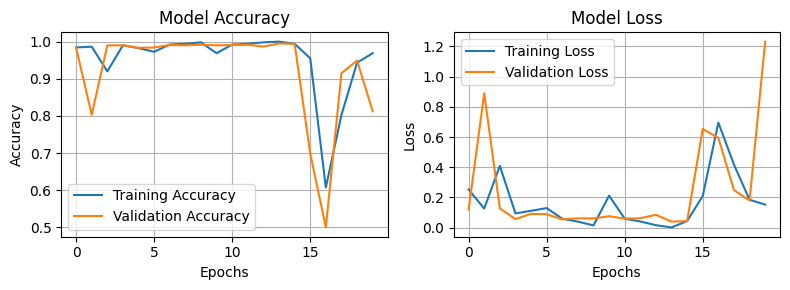

In [152]:
# Create a figure with a subplot
fig_w, fig_h = 4,3
fig, (axs1, axs2) = plt.subplots(1,2,figsize=(2 * fig_w, fig_h ))

# Plot Accuracy on the first subplot
axs1.plot(fit.history['accuracy'], label='Training Accuracy')
axs1.plot(fit.history['val_accuracy'], label='Validation Accuracy')
axs1.set_title('Model Accuracy')
axs1.set_xlabel('Epochs')
axs1.set_ylabel('Accuracy')
axs1.legend()
axs1.grid(True)

# Plot Loss on the second subplot
axs2.plot(fit.history['loss'], label='Training Loss')
axs2.plot(fit.history['val_loss'], label='Validation Loss')
axs2.set_title('Model Loss')
axs2.set_xlabel('Epochs')
axs2.set_ylabel('Loss')
axs2.legend()
axs2.grid(True)

plt.tight_layout()
plt.show()

<a id="vision-transformers-in-pytorch"></a>

### Vision Transformers in PyTorch

First, make sure our directories and random seeds are set. We will use our previously defined set_seed function.

In [153]:
data_dir = "."

pytorch_state_dict_name = "ai_capstone_pytorch_state_dict.pth"
pytorch_state_dict_path = os.path.join(data_dir, pytorch_state_dict_name)
print(f"pytorch_state_dict_path: {os.path.exists(pytorch_state_dict_path)} ___ {pytorch_state_dict_path}")

pytorch_state_dict_path: True ___ .\ai_capstone_pytorch_state_dict.pth


In [154]:
SEED = 42
set_seed(SEED)
print(f"Global seed set to {SEED} - main process is now deterministic.")

Global seed set to 42 - main process is now deterministic.


<a id="define-pre-trained-cnn-backbone"></a>

#### Define pre-trained CNN backbone

In this cell, we will create and implement a **ConvNet** class. This class serves as the convolutional backbone for the hybrid CNN-ViT architecture. 
The design of this class will be the **same as the training architecture**, with six progressive convolutional blocks.

- **`forward_features()`**: Returns the raw convolutional feature map (B, 1024, H, W) for use by the **ViT component**

- **Role in hybrid architecture**: In the hybrid model, this CNN serves as a **local feature extractor**, capturing low-level patterns, edges, and textures before passing the feature-rich representation to the Vision Transformer for global context modeling. The 1024-channel output provides a rich semantic representation that the ViT can process as a sequence of tokens.


In [155]:
class ConvNet(nn.Module):
    ''' 
    Class to define the architecture same as the imported pre-trained CNN model for extracting the` feature map
    '''
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(32),
            nn.Conv2d(32, 64, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(64),
            nn.Conv2d(64, 128, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(128),
            nn.Conv2d(128, 256, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(256),
            nn.Conv2d(256, 512, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(512),
            nn.Conv2d(512, 1024, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(1024)
        )

    def forward_features(self, x):
        return self.features(x)      # (B,1024,H,W)


<a id="patch-embedding"></a>

#### Patch embedding
 The **PatchEmbed** class implements the **interface** between the CNN feature extractor and the Vision Transformer, converting spatial feature maps into a sequence of tokens suitable for self-attention processing.

Unlike traditional ViT implementations that divide raw images into fixed-size patches, this hybrid approach operates on CNN feature maps. The implementation uses a **1×1 convolution** as a learned linear projection to transform the 1024-dimensional CNN features into the transformer's embedding dimension (default 768).

The transformation process involves three key steps:
1. **Channel projection**: `nn.Conv2d(in_ch, embed_dim, kernel_size=1)` reduces or expands the channel dimension from 1024 to the preferred embedding size
2. **Spatial flattening**: `.flatten(2)` collapses the height and width dimensions (H×W) into a single sequence dimension
3. **Tensor reshaping**: `.transpose(1,2)` reorders dimensions from (B, D, L) to (B, L, D) where L=H×W represents the sequence length

**Integration with hybrid architecture**

In the context of the hybrid model, this patch embedding serves as the **bridge** between local CNN features and global transformer processing. Since the CNN has already extracted meaningful local patterns, the patch embedding focuses on format conversion rather than feature extraction. This design is more **efficient** than traditional ViT patch embedding since the CNN has already performed the heavy lifting of feature extraction from raw pixels.

The **output tensor** (B, L, D) represents a batch of sequences where each sequence contains L tokens (corresponding to spatial locations in the feature map) with D-dimensional embeddings ready for transformer processing.


In [156]:
class PatchEmbed(nn.Module):
    def __init__(self, input_channel=1024, embed_dim=768):
        super().__init__()
        self.proj = nn.Conv2d(input_channel, embed_dim, kernel_size=1)  # 1×1 conv
    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)  # (B,L,D)
        return x

<a id="multi-head-self-attention-mhsa-module"></a>

#### Multi-head self-attention (MHSA) module

The **MHSA** class implements the self-attention mechanism that enables the Vision Transformer to model long-range dependencies and global context across all spatial locations in the feature map.

The implementation follows the scaled dot-product attention formula: **Attention(Q,K,V) = softmax(QK^T/√d)V**, where Q, K, and V represent query, key, and value matrices, respectively. The scaling factor 1/sqrt(d) prevents the dot products from becoming too large, which would push the softmax function into regions with extremely small gradients.

The multi-head mechanism splits the embedding dimension across multiple attention heads, allowing the model to attend to different types of relationships simultaneously. 

##### Key implementation details:

- **Unified QKV projection**: A single linear layer `nn.Linear(dim, dim*3)` generates Q, K, and V matrices efficiently, reducing memory overhead compared to separate projections
- **Head reshaping**: The tensor is reshaped from (B, N, D) to (B, heads, N, d) where d = D/heads, enabling parallel processing across heads
- **Attention computation**: Matrix multiplication `torch.matmul(q, k.transpose(-2, -1))` computes attention scores, followed by scaling and softmax normalization
- **Dropout regularization**: Two dropout layers prevent overfitting - one on attention weights and one on the final output


Unlike CNNs, which have limited receptive fields, self-attention allows every token to interact directly with every other token in a single operation. This enables the model to **capture long-range spatial dependencies** that might be missed by purely convolutional approaches. 

**In the hybrid architecture, this global modeling complements the local feature extraction performed by the CNN backbone.**

The attention weights provide interpretability, showing which spatial locations the model focuses on when making predictions. This component is valuable for both performance and explainability.


In [157]:
class MHSA(nn.Module):
    def __init__(self, dim, heads=8, dropout=0.):
        super().__init__()
        self.heads = heads
        self.scale = (dim // heads) ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.attn_drop = nn.Dropout(dropout)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(dropout)
    def forward(self, x):
        B, N, D = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = q.reshape(B, N, self.heads, -1).transpose(1, 2)  # (B, heads, N, d)
        k = k.reshape(B, N, self.heads, -1).transpose(1, 2)
        v = v.reshape(B, N, self.heads, -1).transpose(1, 2)
        attn = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        attn = self.attn_drop(attn.softmax(dim=-1))
        x = torch.matmul(attn, v).transpose(1, 2).reshape(B, N, D)
        return self.proj_drop(self.proj(x))

<a id="transformer-block"></a>

#### Transformer block
This code defines a building block used in modern deep learning models, especially in Vision Transformers. The class is called TransformerBlock, and it is responsible for helping the model “pay attention” to the most important parts of its input and improve the final predictions.

Let’s break down what happens inside:

**Layer normalization (nn.LayerNorm):** This helps stabilize and speed up training by normalizing each row of the input data, which is useful before applying attention or a neural network layer.

**Attention layer (MHSA):** This is the “Multi-Head Self Attention” block. It enables the model to look at all positions in the sequence (or image patches) at once, figuring out which ones are most important for each output. It’s like giving the model the power to focus on the key parts of an image or sentence.

**MLP (nn.Sequential):** This is a **Multi-Layer Perceptron** or a mini neural network, made up of linear (fully connected) layers, a special activation (GELU), and dropout for regularization. This MLP has:
- One linear layer that expands the input dimension by mlp_ratio (for example, 4× wider).
- A GELU activation function (a nonlinear operation, similar to ReLU).
- Dropout for regularization (helps prevent overfitting).
- Another linear layer that shrinks the data back to the original dimension.
- Another dropout layer.
Here, MLP is designed to help the model learn better representations by combining and transforming the information after the attention step.

**Skip/Residual connections (x + ...):** These connections support effective and stable training for deep neural networks by keeping pathways open for both forward information flow and backward gradient flow, making deep architectures such as transformers possible and practical. In transformers, skip connections are placed around both the attention and feedforward (MLP) sub-layers in each block. This stabilizes training of these very deep, stackable models, improves convergence speed, and lets them scale to larger datasets and more complex tasks.

In summary, this block helps models understand relationships in their input data, making them more powerful for tasks such as image and language understanding!


In [158]:
class TransformerBlock(nn.Module):
    def __init__(self, dim, heads, mlp_ratio=4., dropout=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = MHSA(dim, heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
                                    nn.Linear(dim, int(dim * mlp_ratio)),
                                    nn.GELU(), nn.Dropout(dropout),
                                    nn.Linear(int(dim * mlp_ratio), dim),
                                    nn.Dropout(dropout))
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

<a id="vision-transformer-vit-model"></a>

#### Vision Transformer (ViT) model

The **ViT** class represents the complete Vision Transformer implementation, including patch embedding, positional encoding, transformer blocks, and a classification head for global context modeling.

The implementation uses a learnable **Classification [CLS] token**:
- **Initialization**: `nn.Parameter(torch.zeros(1, 1, embed_dim))` creates a learnable token initialized to zeros
- **Expansion**: `self.cls.expand(B, -1, -1)` replicates the token across the batch dimension
- **Prepending**: `torch.cat((cls, x), 1)` concatenates the CLS token to the beginning of the sequence
- **Classification**: Only the CLS token representation is used for final classification

This allows the CLS token to aggregate information from all spatial locations through self-attention, creating a global representation suitable for classification.

`nn.Parameter(torch.randn(1, max_tokens, embed_dim))` creates a large positional embedding matrix
and `self.pos[:, :L+1]` dynamically slices the positional embeddings to match the actual sequence length. Together, these create a **dynamic positional encoding** system for the hybrid architecture where the CNN feature map size can vary based on input image dimensions.


**`depth`** defines the number of transformerBlocks to be used in the transformer encoder
##### Classification head design

The final classification pipeline includes:
1. **Final normalization**: `self.norm(x)` applies LayerNorm to the final transformer output
2. **CLS token extraction**: `[:, 0]` selects only the CLS token representation
3. **Linear classification**: `self.head` maps the CLS representation to class logits

The model's ability to handle variable sequence lengths makes it robust to different input sizes and CNN architectures, providing flexibility in deployment scenarios.


In [159]:
class ViT(nn.Module):
    def __init__(self, in_ch=1024, num_classes=2,
                 embed_dim=768, depth=6, heads=8,
                 mlp_ratio=4., dropout=0.1, max_tokens=50):
        super().__init__()
        self.patch = PatchEmbed(in_ch, embed_dim)           # 1×1 conv
        self.cls   = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos   = nn.Parameter(torch.randn(1, max_tokens, embed_dim))
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, heads, mlp_ratio, dropout)
            for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):                          # x: (B,C,H,W)
        x = self.patch(x)                          # (B,L,D)
        B, L, _ = x.shape
        cls = self.cls.expand(B, -1, -1)           # (B,1,D)
        x = torch.cat((cls, x), 1)                 # (B,L+1,D)
        x = x + self.pos[:, :L + 1]                # match seq-len
        for blk in self.blocks:
            x = blk(x)
        return self.head(self.norm(x)[:, 0])       # CLS token

<a id="cnn-vit-hybrid-model"></a>

#### CNN-ViT hybrid model

The **CNN_ViT_Hybrid** class represents the hybrid architecture, integrating the CNN backbone with the Vision Transformer to create a unified model that leverages both local and global feature processing capabilities.
In this hybrid model, the pre-trained CNN layers can be frozen while fine-tuning the Vi and allows for **efficient attention** to operate on semantically rich CNN features rather than raw pixels
Thus, this hybrid approach combines the excellent capabilities of CNN to capture local patterns efficiently with ViTs' global context modeling, while keeping the level of complexity low.

The forward pass implements a **two-stage forward pass pipeline**:
1. **Local feature extraction**: `self.cnn.forward_features(x)` processes the input image through the CNN backbone, extracting hierarchical local features and reducing spatial resolution while increasing semantic depth.
2. **Global context modeling**: `self.vit(features)` takes the CNN feature map and processes it through the Vision Transformer for global reasoning and classification.

Despite the modular design, the entire hybrid model remains **fully differentiable**, enabling end-to-end training where gradients could flow from the classification loss back through both the ViT and CNN components. This allows the CNN to learn features that are optimally suited for the downstream transformer processing, creating a synergistic relationship between the two architectures.


In [160]:
class CNN_ViT_Hybrid(nn.Module):
    def __init__(self, num_classes=2, embed_dim=768, depth=6, heads=8):
        super().__init__()
        self.cnn = ConvNet(num_classes)            # load weights later
        self.vit = ViT(num_classes=num_classes,
                       embed_dim=embed_dim,
                       depth=depth,
                       heads=heads)
    def forward(self, x):
        return self.vit(self.cnn.forward_features(x))

<a id="model-training"></a>

#### Model training

The **train** function implements a comprehensive training loop for one epoch, handling forward propagation, loss computation, backpropagation, and metric tracking in a memory-efficient manner.

**Training mode**
The function begins with `model.train()`, which configures the model for training by enabling dropout layers and gradient computation

**Batch processing pipeline**
Each training iteration follows a standard deep learning pipeline:

1. **Data transfer**: `x, y = x.to(device), y.to(device)` moves input data and labels to the appropriate device (CPU/GPU)
2. **Gradient reset**: `optimizer.zero_grad()` clears gradients from the previous iteration to prevent accumulation
3. **Forward pass**: `out = model(x)` computes predictions through the hybrid CNN-ViT architecture
4. **Loss computation**: `loss = criterion(out, y)` calculates cross-entropy loss between predictions and ground truth
5. **Backpropagation**: `loss.backward()` computes gradients via automatic differentiation
6. **Parameter update**: `optimizer.step()` updates model parameters using the computed gradients

**Metric accumulation**: The function tracks two key metrics:
- **Weighted loss**: `loss.item() * x.size(0)` accumulates loss weighted by batch size for accurate averaging
- **Correct predictions**: `(out.argmax(1) == y).sum().item()` counts correct predictions using argmax for multi-class classification


In [161]:
def train(model, loader, optimizer, criterion, device):
    model.train()
    loss_sum, correct = 0, 0
    for batch_idx, (x, y) in enumerate(tqdm(loader, desc="Training  ")):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
    return loss_sum / len(loader.dataset), correct / len(loader.dataset)

<a id="model-evaluation"></a>

#### Model evaluation
Here, we will evaluate the model, implementing inference without gradient computation to optimize memory usage and computational speed.

Two fundamental differences between using the model for evaluation and testing versus training are:
- **`torch.no_grad()`**:  Disables gradient computation and accelerate inference
- **`model.eval()`**: Switches the model to evaluation mode, ensures deterministic outputs

The **evaluation loop** mirrors the training loop structure but omits gradient-related operations.

This function **integrates with the training pipeline**, providing regular validation checks that help monitor model progress, detect overfitting, and make informed decisions about training continuation, learning rate adjustments, and model selection. The consistent interface with the training function enables easy integration into automated training workflows.


In [162]:
def evaluate(model, loader, criterion, device):
    with torch.no_grad():
        model.eval()
        loss_sum, correct = 0, 0
        for batch_idx, (x, y) in enumerate(tqdm(loader, desc="Validation")):
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            loss_sum += loss.item() * x.size(0)
            correct  += (out.argmax(1) == y).sum().item()
    return loss_sum / len(loader.dataset), correct / len(loader.dataset)

<a id="data-preparation-and-loading"></a>

#### Data preparation and loading

Here, we implement data preparation for the entire data pipeline, from raw image loading to batched tensor delivery.

We define the key training hyperparameters:
- **Image size (64×64)**: Chosen for computational efficiency while maintaining sufficient resolution for feature extraction
- **Batch size (128)**: Balances memory usage with gradient stability and training speed
- **learning rate (0.001)**: A conservative number for learning
- **number of classes**: Total number of classes to be classified by the model


In [163]:
dataset_path = os.path.join(data_dir, "images_dataSAT")

img_size = 64
batch_size = 32
lr = 0.001
num_cls  = 2


#### Training data transformations
The **training transform** pipeline implements several **augmentation techniques** including Random Rotation, Random Horizontal Flip, Random Affine with Shear and normalization.


We will create `train_transform` transforms for the training dataset using the following parameters:
- Size: `img_size x img_size`
- `RandomRotation`: 40
- `RandomHorizontalFlip`
- `RandomAffine(0, shear=0.2)`
- `Normalization` values: ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])


In [164]:
train_transform = transforms.Compose([transforms.Resize((img_size, img_size)),
                                      transforms.RandomRotation(40),
                                      transforms.RandomHorizontalFlip(),
                                      transforms.RandomAffine(0, shear=0.2),
                                      transforms.ToTensor(),
                                      transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
                                     ])

#### Validation data transformations
The **validation transform** is minimal for **deterministic preprocessing** to ensure reproducible validation results


We will create `val_transform` transforms for the validation dataset using the following parameters:
- Size: `img_size x img_size`
- `Normalization` values: ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])


In [165]:
val_transform = transforms.Compose([transforms.Resize((img_size,img_size)),
                                    transforms.ToTensor(),
                                    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
                                   ])

#### The DataLoader

The DataLoader setup is optimized for training:
- **Shuffling**: Training data is shuffled to prevent batch-level patterns
- **No Validation Shuffling**: Validation order is consistent for reproducible results
- **`batch_size`**: Efficient tensor batching for GPU utilization

We begin by splitting the dataset into `training` and `validation` data using `random_split` feature. Here, qw define **80%** (0.8 fraction) of the total dataset for training and rest for validation.

Next, we apply the `train_transform` to `train_dataset` and `val_transform` to `val_dataset` to make the dataset ready for DataLoader


In [166]:
full_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

Let's create the Dataloader `train_loader` and `val_loader` using `train_dataset` and `val_dataset` using the following parameters:
- `batch_size=batch_size`
- for `train_loader`: `shuffle=True`
- for `val_loader`: `shuffle=False`


In [167]:
train_loader = DataLoader(train_dataset,
                          batch_size=batch_size,
                          shuffle=True,
                         )

val_loader = DataLoader(val_dataset,
                        batch_size=batch_size,
                        shuffle=False,
                       )

<a id="model-initialization-and-training-loop"></a>

#### Model initialization and training loop

This cell orchestrates the complete training pipeline, from model instantiation through iterative training and validation, implementing comprehensive monitoring and logging for effective model development.

- **CUDA detection**: `torch.cuda.is_available()` checks for GPU availability

The hybrid model is instantiated with carefully chosen hyperparameters:
- **Number of classes**: `num_classes=2` configured for the specific dataset
- **Default architecture**: Uses ViT configuration (768 embedding dim, 1  transformer layer, 1 heads)

#### Transfer learning integration

The commented line demonstrates transfer learning capability:
- **Pre-trained weights**: Option to load pre-trained CNN backbone weights
- **Flexible loading**: `strict=False` allows partial weight loading

**Optimizer**: The training uses the `adam` optimizer.

The training loop collects the **training and validation metrics** to track training performance and monitor generalization of the model.

#### Training loop architecture

Each epoch follows a structured pipeline:
1. **Timing**: `time.time()` tracks epoch duration for performance monitoring
2. **Training phase**: Calls the training function with appropriate parameters
3. **Validation phase**: Evaluates model on validation set
4. **Logging**: Comprehensive output showing all metrics and timing
5. **Storage**: Appends metrics to tracking lists for later analysis

In this training cell, you create a robust, monitored, and efficient training pipeline that provides comprehensive insights into model performance while maintaining computational efficiency and enabling easy debugging and optimization.


In [168]:
device   = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Training the model on {device}")


epochs     = 20
attn_heads = 6
depth      = 3
embed_dim  = 768

print(f"epochs:{epochs} | batch:{batch_size} | attn_heads:{attn_heads} | depth:{depth} | embed_dim:{embed_dim}")

model_dict_name = f"ai_capstone_pytorch_vit_model_state_dict.pth"

model     = CNN_ViT_Hybrid(num_classes=num_cls,
                            heads=attn_heads,
                            depth=depth,
                            embed_dim=embed_dim
                           ).to(device)


# ------------------------------------------------------------------ #
# loading pre-trained CNN weights
model.cnn.load_state_dict(torch.load(pytorch_state_dict_path), strict=False)
# ------------------------------------------------------------------ #


criterion= nn.CrossEntropyLoss()
optimizer= torch.optim.Adam(model.parameters(), lr=lr)


best_loss = float('inf')
tr_loss_all = []
te_loss_all = []
tr_acc_all = []
te_acc_all = []

training_time = []
for epoch in range(1, epochs+1):
    start_time = time.time()
    print(f"\nEpoch {epoch:02d}/{epochs:02d} started at {present_time()} (UTC)")
    tr_loss,tr_acc = train(model, train_loader, optimizer, criterion, device)
    te_loss,te_acc = evaluate(model, val_loader, criterion, device)
    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {te_loss:.4f} acc {te_acc:.4f} |"
          f" in  {time.time()-start_time:.02f}s"
        )
    tr_loss_all.append(tr_loss)
    te_loss_all.append(te_loss)
    tr_acc_all.append(tr_acc)
    te_acc_all.append(te_acc)
    training_time.append(time.time() - start_time)
    
    # Save the best model
    avg_te_loss = te_loss
    if avg_te_loss < best_loss:
        print(f"Current loss ({avg_te_loss:.04f}) lower than previous best loss ({ best_loss:.04f}), Saving current model state")
        best_loss = avg_te_loss
        torch.save(model.state_dict(), model_dict_name)

print(f"epochs:{epochs} | batch:{batch_size} | attn_heads:{attn_heads} | depth:{depth} | embed_dim:{embed_dim}")


Training the model on cpu
epochs:20 | batch:32 | attn_heads:6 | depth:3 | embed_dim:768

Epoch 01/20 started at 20260326_185010 (UTC)


Validation: 100%|██████████| 38/38 [00:01<00:00, 25.20it/s]


Epoch 01 | train loss 0.2907 acc 0.9419 | val loss 0.0157 acc 0.9950 | in  24.54s
Current loss (0.0157) lower than previous best loss (inf), Saving current model state

Epoch 02/20 started at 20260326_185034 (UTC)


Validation: 100%|██████████| 38/38 [00:01<00:00, 26.51it/s]


Epoch 02 | train loss 0.0712 acc 0.9748 | val loss 0.0309 acc 0.9850 | in  24.53s

Epoch 03/20 started at 20260326_185059 (UTC)


...

Epoch 18 | train loss 0.0143 acc 0.9950 | val loss 0.0108 acc 0.9975 | in  22.59s
Current loss (0.0108) lower than previous best loss (0.0136), Saving current model state

Epoch 19/20 started at 20260326_185722 (UTC)


Validation: 100%|██████████| 38/38 [00:01<00:00, 26.33it/s]


Epoch 19 | train loss 0.0308 acc 0.9877 | val loss 0.0126 acc 0.9950 | in  22.34s

Epoch 20/20 started at 20260326_185745 (UTC)


Validation: 100%|██████████| 38/38 [00:01<00:00, 26.80it/s]

Epoch 20 | train loss 0.0195 acc 0.9921 | val loss 0.0153 acc 0.9950 | in  23.35s
epochs:20 | batch:32 | attn_heads:6 | depth:3 | embed_dim:768


<a id="hyperparameter-cheatsheet-depth-based"></a>

#### Hyperparameter cheatsheet (depth based)

The Depth of the transformer blocks signify the number of transformer blocks stacked in the model. This is one of the most important features which differentiates a ViT from CNN.

This table proides a basic overview on **how depth affects** other hyperparameters and model performance.

|  **Depth** | **Attention heads** | **Dataset Size** |  **Performance** | **learning rate** | **Feature Complexity** | **Learning Focus** |
|:---:|:---:|---|:---:|---|:---|:---:|
| **3** | 6 | size < 1000 | Underfitting - too shallow |0.001 (Shallow: can handle higher learning rates) | Low-level features | Edges, textures, basic patterns |
| **6** | 6 | size <1000 | Good for simple tasks |0.001 (Shallow: can handle higher learning rates) | Mid-level features | Shapes, object parts, spatial relationships |
| **12** | 12 | 1000 < size < 10000 | Standard choice - good balance | 0.0005 (Medium: moderate learning rate) | High-level features | Objects, semantic concepts, global context |
| **18** | 12 | 10000 < size < 100000 | High performance on complex tasks | 0.0003 (Deep: lower learning rate for stability) | High-level features | Objects, semantic concepts, global context |
| **24** | 16 | 100000 < size | Diminishing returns, overfitting risk | 0.0001 (Very deep: very small learning rate) | High-level features | Objects, semantic concepts, global context |
| **36** | 16 | 100000 < size | Likely overkill for most tasks | 0.0001 (Very deep: very small learning rate) | High-level features | Objects, semantic concepts, global context |


<a id="plotting-training-and-validation-accuracy-and-loss"></a>

#### Plotting training and validation accuracy and loss

This visualization cell creates comprehensive learning curves that provide crucial insights into model training dynamics, performance trends, and potential issues such as overfitting or underfitting.

The implementation creates two separate plots for different aspects of training analysis:
- **Accuracy plot**: Shows classification performance trends over epochs
- **Loss plot**: Reveals optimization dynamics and convergence behavior


These plots enable several important diagnostic assessments:
- **Overfitting detection**: Widening gap between training and validation metrics
- **Underfitting identification**: Both metrics plateau at suboptimal levels
- **Training completion**: Convergence indicates when to stop training
- **Hyperparameter evaluation**: Curves help assess learning rate, regularization effectiveness

These learning curves serve as essential tools for understanding model behavior, diagnosing training issues, and making informed decisions about hyperparameter adjustments, training duration, and model architecture modifications.


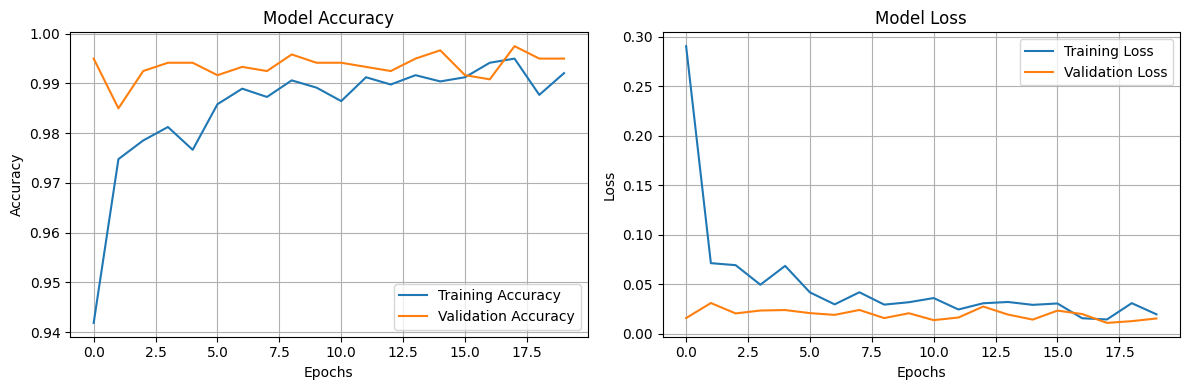

In [169]:
fig_w, fig_h = 6,4
fig, (axs1, axs2) = plt.subplots(1,2,figsize=(2* fig_w, fig_h ))

# Plot Accuracy on the first subplot
axs1.plot(tr_acc_all, label='Training Accuracy')
axs1.plot(te_acc_all, label='Validation Accuracy')
axs1.set_title('Model Accuracy')
axs1.set_xlabel('Epochs')
axs1.set_ylabel('Accuracy')
axs1.legend()
axs1.grid(True)


# Plot Loss on the second subplot
axs2.plot(tr_loss_all, label='Training Loss')
axs2.plot(te_loss_all, label='Validation Loss')
axs2.set_title('Model Loss')
axs2.set_xlabel('Epochs')
axs2.set_ylabel('Loss')
axs2.legend()
axs2.grid(True)

plt.tight_layout()
plt.show()

<a id="part-4---model-evaluation-keras-vs-pytorch"></a>

## Part 4 - Model Evaluation: Keras vs. PyTorch

Make sure our model and dataset paths are correct.

In [171]:
data_dir = "."
keras_model_name = "keras_cnn_vit.model.keras"
keras_model_path = os.path.join(data_dir, keras_model_name)
print(f"keras_model_path: {os.path.exists(keras_model_path)} ___ {keras_model_path}")

pytorch_state_dict_name = "ai_capstone_pytorch_vit_model_state_dict.pth"
pytorch_state_dict_path = os.path.join(data_dir, pytorch_state_dict_name)
print(f"pytorch_state_dict_path: {os.path.exists(pytorch_state_dict_path)} ___ {pytorch_state_dict_path}")

keras_model_path: True ___ .\keras_cnn_vit.model.keras
pytorch_state_dict_path: True ___ .\ai_capstone_pytorch_vit_model_state_dict.pth


Fix our random seed for reproducibility.

In [172]:
SEED = 42
set_seed(SEED)
print(f"Global seed set to {SEED} - Processes are now deterministic.")

Global seed set to 42 - Processes are now deterministic.


<a id="define-pytorch-model-architecture"></a>

#### Define PyTorch model architecture
In this cell, we will define the PyTorch CNN-ViT model architegcture, exactly as defined during the model training. You define the classes for CNN feature extractor, patch embedding, multi-head self-attention, transformer block, ViT, and CNN-ViT hybrid. 

The `evaluate` function computes loss and accuracy. This architecture combines CNN local features with ViT global attention. 

Parameters like depth and heads are configurable, and defined same as during training.


In [173]:
#====================
class ConvNet(nn.Module):
    ''' 
    Class to define the architecture same as the imported pre-trained CNN model
    '''
    def __init__(self, num_classes: int):
        super().__init__()
        # -------- convolutional feature extractor --------
        self.features = nn.Sequential(
            nn.Conv2d(3, 32,  kernel_size=5, padding=2), nn.ReLU(inplace=True), nn.MaxPool2d(2), nn.BatchNorm2d(32),
            nn.Conv2d(32, 64,  kernel_size=5, padding=2), nn.ReLU(inplace=True), nn.MaxPool2d(2), nn.BatchNorm2d(64),
            nn.Conv2d(64, 128, kernel_size=5, padding=2), nn.ReLU(inplace=True), nn.MaxPool2d(2), nn.BatchNorm2d(128),
            nn.Conv2d(128, 256, kernel_size=5, padding=2), nn.ReLU(inplace=True), nn.MaxPool2d(2), nn.BatchNorm2d(256),
            nn.Conv2d(256, 512, kernel_size=5, padding=2), nn.ReLU(inplace=True), nn.MaxPool2d(2), nn.BatchNorm2d(512),
            nn.Conv2d(512, 1024, kernel_size=5, padding=2), nn.ReLU(inplace=True), nn.MaxPool2d(2), nn.BatchNorm2d(1024),
        )

        # -------- global pooling + classifier head --------
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(nn.Flatten(),                           # flatten feature map of dimensions (1024 × 1 × 1) to 1024
                                        nn.Linear(1024, 2048), nn.ReLU(inplace=True), nn.BatchNorm1d(2048), nn.Dropout(0.4), 
                                        nn.Linear(2048, num_classes)
                                       )

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        return self.features(x)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.forward_features(x)   # features, dimensions:(B, 1024, H', W')
        x = self.pool(x)               # global-average-pooling, dimensions: (B, 1024, 1, 1)
        x = self.classifier(x)         # classifier, dimensions: (B, num_classes)
        return x

#====================
class PatchEmbed(nn.Module):
    def __init__(self, input_channel=1024, embed_dim=768):
        super().__init__()
        self.proj = nn.Conv2d(input_channel, embed_dim, kernel_size=1)  # 1×1 conv
    
    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)  # (B,L,D)
        return x

#====================
class MHSA(nn.Module):
    def __init__(self, dim, heads=8, dropout=0.):
        super().__init__()
        self.heads = heads
        self.scale = (dim // heads) ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.attn_drop = nn.Dropout(dropout)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(dropout)
    
    def forward(self, x):
        B, N, D = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = q.reshape(B, N, self.heads, -1).transpose(1, 2)  # (B, heads, N, d)
        k = k.reshape(B, N, self.heads, -1).transpose(1, 2)
        v = v.reshape(B, N, self.heads, -1).transpose(1, 2)
        attn = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        attn = self.attn_drop(attn.softmax(dim=-1))
        x = torch.matmul(attn, v).transpose(1, 2).reshape(B, N, D)
        return self.proj_drop(self.proj(x))

#====================
class TransformerBlock(nn.Module):
    def __init__(self, dim, heads, mlp_ratio=4., dropout=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = MHSA(dim, heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
                                    nn.Linear(dim, int(dim * mlp_ratio)),
                                    nn.GELU(), nn.Dropout(dropout),
                                    nn.Linear(int(dim * mlp_ratio), dim),
                                    nn.Dropout(dropout))
    
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

#====================
class ViT(nn.Module):
    def __init__(self, in_ch=1024, num_classes=2,
                 embed_dim=768, depth=6, heads=8,
                 mlp_ratio=4., dropout=0.1, max_tokens=50):
        super().__init__()
        self.patch = PatchEmbed(in_ch, embed_dim)           # 1×1 conv
        self.cls   = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos   = nn.Parameter(torch.randn(1, max_tokens, embed_dim))
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, heads, mlp_ratio, dropout)
            for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):                          # x: (B,C,H,W)
        x = self.patch(x)                          # (B,L,D)
        B, L, _ = x.shape
        cls = self.cls.expand(B, -1, -1)           # (B,1,D)
        x = torch.cat((cls, x), 1)                 # (B,L+1,D)
        x = x + self.pos[:, :L + 1]                # match seq-len
        for blk in self.blocks:
            x = blk(x)
        return self.head(self.norm(x)[:, 0])       # CLS token

#====================
class CNN_ViT_Hybrid(nn.Module):
    def __init__(self, num_classes=2, embed_dim=768, depth=6, heads=8):
        super().__init__()
        self.cnn = ConvNet(num_classes)            # load weights later
        self.vit = ViT(num_classes=num_classes,
                       embed_dim=embed_dim,
                       depth=depth,
                       heads=heads)
    
    def forward(self, x):
        return self.vit(self.cnn.forward_features(x))

#====================
def evaluate(model, loader, criterion, device):
    with torch.no_grad():
        model.eval()
        loss_sum, correct = 0, 0
        for batch_idx, (x, y) in enumerate(tqdm(loader, desc="Validation")):
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            loss_sum += loss.item() * x.size(0)
            correct  += (out.argmax(1) == y).sum().item()
    return loss_sum / len(loader.dataset), correct / len(loader.dataset)# Set device

#### Dataset path and hyperparameters
Here, we set the dataset path and hyperparameters like image size, channels, batch size, classes, and labels. These are used for data loading and model configuration. Consistent dimensions ensure compatibility with model inputs.


Let's define the dataset directory, dataloader and model hyperparameters. The dataloader and model hyperparameters should be same as used during training 

- Define the `dataset_path`

- Define **hyperparameters common dataloader**
    - `img_w`, `img_h = 64, 64`
    - `batch_size = 128`
    - `num_classes = 2`
    - `agri_class_labels = ["non-agri", "agri"]`

  
- Define **hyperparameters for PyTorch CNN-Vit Hybrid model**. The values have to same as those used while training the hybrid model. 
    - `depth = 3`
    - `attn_heads = 6`
    - `embed_dim = 768`



In [174]:
## Please use the space below to write your answer
dataset_path = os.path.join(data_dir,"images_dataSAT")

#Common Dataloader Hyperparameters
img_w, img_h = 64,64
batch_size = 128
num_classes = 2
agri_class_labels = ["non-agri","agri"]

#Hybrid Model hyperparameters
depth = 3
attn_heads = 6
embed_dim = 768

<a id="pytorch-dataloader"></a>

#### PyTorch Dataloader
Defines transforms for resizing, tensor conversion, and normalization (ImageNet means/std). 

Loads dataset with ImageFolder and creates DataLoader for batching without shuffling for evaluation.


In [175]:
train_transform = transforms.Compose([
    transforms.Resize((img_w, img_h)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
full_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)
test_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False)

#### Instantiate PyTorch model
Check the availability of CUDA device and set the `device` parameter accordingly.

Based on the `CNN_ViT_Hybrid` function, instantiate the PyTorch model and move the model to the available `device`

In this cell, we will:
1. instantiate the PyTorch CNN_ViT_Hybrid with the previously declared model parameters
3. detect the device for model inference
 


In [177]:
#Check device availability
device = "cuda" if torch.cuda.is_available() else "cpu"

#Instantiate model
pytorch_model = CNN_ViT_Hybrid(num_classes=num_classes,
                       heads=attn_heads,
                       depth=depth,
                       embed_dim=embed_dim
                      ).to(device)

print(f"Evaluating the PyTorch model on {device}")

Evaluating the PyTorch model on cpu


<a id="----pytorch-pre-trained-model-loading----"></a>

#### --- PyTorch pre-trained ViT model loading ---
In this cell, we load the PyTorch model state dict with **`strict=False`** for flexibility.

Thus, we prepare the model for inference.


In [179]:
# Load pre-trained CNN-ViT hybrid model weights 
if device=="cpu":
    map_location=torch.device("cpu")
else:
    map_location=torch.device("cuda")

pytorch_model.load_state_dict(torch.load(pytorch_state_dict_path, map_location=map_location), strict=False)
print("Loaded model state dict.")

Loaded model state dict.


<a id="pytorch-model-inference-metrics"></a>

#### PyTorch model inference metrics

Now, we perform:
1. inference on test_loader
2. collecte prediction, labels, and probabilities (for class 1)
3. Uses no_grad for efficiency and eval mode
4. Use tqdm to show progress.
5. Move the data to the training device (CPU/GPU).


In [180]:
%%time
all_preds_pytorch = []
all_labels_pytorch = []
all_probs_pytorch = []

pytorch_model.eval()
with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(tqdm(test_loader, desc="Step")):
#    for images, labels in test_loader:
        images = images.to(device)
        outputs = pytorch_model(images)
        preds = torch.argmax(outputs, dim=1)
        probs = F.softmax(outputs, dim=1)[:, 1]  # probability for class 1
        all_probs_pytorch.extend(probs.cpu())
        all_preds_pytorch.extend(preds.cpu().numpy().flatten())
        all_labels_pytorch.extend(labels.numpy())

Step: 100%|██████████| 47/47 [00:05<00:00,  7.85it/s]

CPU times: total: 41.2 s
Wall time: 5.99 s


<a id="keras-model-loading"></a>

#### Keras model loading

To load the Keras based CNN-ViT hybrid model, we will

- define **custom Keras layers** with serialization for model saving/loading for:
    - `position embedding`
    - `transformer block`

This step is essential for reconstructing the ViT architecture in Keras.


In [181]:
# Positional embedding that Keras can track
@tf.keras.utils.register_keras_serializable(package="Custom")
class AddPositionEmbedding(layers.Layer):
    def __init__(self, num_patches, embed_dim, **kwargs):
        super(AddPositionEmbedding, self).__init__(**kwargs)
        self.num_patches = num_patches
        self.embed_dim   = embed_dim
        self.pos = self.add_weight(
            name="pos_embedding",
            shape=(1, num_patches, embed_dim),
            initializer="random_normal",
            trainable=True)

    def call(self, tokens):
        return tokens + self.pos

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "embed_dim":   self.embed_dim,
        })
        return {**config}

# One Transformer encoder block
@tf.keras.utils.register_keras_serializable(package="Custom")
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads=8, mlp_dim=2048, dropout=0.1, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.mlp_dim   = mlp_dim
        self.dropout   = dropout
        self.mha  = layers.MultiHeadAttention(num_heads, key_dim=embed_dim)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = tf.keras.Sequential([
            layers.Dense(mlp_dim, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(embed_dim),
            layers.Dropout(dropout)
        ])

    def call(self, x):
        x = self.norm1(x + self.mha(x, x))
        return self.norm2(x + self.mlp(x))

    # ---- NEW ----
    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim":  self.embed_dim,
            "num_heads":  self.num_heads,
            "mlp_dim":    self.mlp_dim,
            "dropout":    self.dropout,
        })
        return {**config}

<a id="----keras-pre-trained-vit-model-loading----"></a>

#### --- Keras pre-trained ViT model loading ---

Here, you will load the pre-trained Keras model using **`load_model`**, providing **custom objects** for deserialization of user-defined layers. This enables inference with the hybrid model.


In [183]:
# ------------------- load CNN-ViT hybrid model ------------------
keras_model = load_model(keras_model_name,
                         custom_objects={
                         "AddPositionEmbedding": AddPositionEmbedding,
                         "TransformerBlock":     TransformerBlock
                          })

<a id="define-dataloader"></a>

#### Define dataloader

In this cell, we create an ImageDataGenerator for rescaling and a generator for flowing images from directory, matching PyTorch setup for consistent evaluation.


In [184]:
datagen = ImageDataGenerator(rescale=1./255)
prediction_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_w, img_h),
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

Found 6000 images belonging to 2 classes.


<a id="collecting-metrics-for-keras-based-cnn-vit-hybrid-model"></a>

#### Collecting metrics for Keras-based CNN-ViT hybrid model
Now, we run the inference of the Keras-based CNN-ViT hybrid model and collect the evaluation metrics.


In [185]:
%%time

all_probs_keras = keras_model.predict(prediction_generator, verbose=1)
all_preds_keras = np.argmax(all_probs_keras, axis=1)
all_labels_keras = prediction_generator.classes

47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step
CPU times: total: 23.2 s
Wall time: 5.31 s


#### Import the evaluation metrics

Here you define the functions to compute and print classification metrics including accuracy, precision, recall, F1 score, ROC-AUC, confusion matrix, and log loss. These functions support both Keras and PyTorch model outputs.


In [192]:
%%time
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             roc_curve, 
                             roc_auc_score,
                             log_loss,
                             classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay,
                            )
from sklearn.preprocessing import label_binarize

# define a function to get the metrics comprehensively
def model_metrics(y_true, y_pred, y_prob, class_labels):
    y_prob = np.array(y_prob)
    if len(y_prob.shape)<2:
        roc_score = roc_auc_score(y_true, y_prob)
    elif len(y_prob.shape)==2:
        roc_score = roc_auc_score(y_true, y_prob[:,1])
    else:
        roc_score = np.nan
    metrics = {'Accuracy': accuracy_score(y_true, y_pred),
               'Precision': precision_score(y_true, y_pred),
               'Recall': recall_score(y_true, y_pred),
               'Loss': log_loss(y_true, y_prob),
               'F1 Score': f1_score(y_true, y_pred),
               'ROC-AUC': roc_score,
               'Confusion Matrix': confusion_matrix(y_true, y_pred),
               'Classification Report': classification_report(y_true, y_pred, target_names=class_labels, digits=4),
               "Class labels": class_labels
              }
    return metrics

#function to print the metrics
def print_metrics(y_true, y_pred, y_prob, class_labels, model_name):
    metrics = model_metrics(y_true, y_pred, y_prob, class_labels)
    
    print(f"Evaluation metrics for the {model_name}")
    print(f"Accuracy: {'':<1}{metrics['Accuracy']:.4f}")
    if metrics["ROC-AUC"] != np.nan:
        print(f"ROC-AUC: {'':<2}{metrics['ROC-AUC']:.4f}")
    print(f"Loss: {'':<5}{metrics['Loss']:.4f}\n")
    print(f"Classification report:\n\n  {metrics['Classification Report']}")
    print("========= Confusion Matrix =========")
    disp = ConfusionMatrixDisplay(confusion_matrix=metrics['Confusion Matrix'],
                                  display_labels=metrics['Class labels'])

    disp.plot()
    plt.show()


CPU times: total: 0 ns
Wall time: 0 ns


<a id="keras-metrics-reporting"></a>

#### Keras metrics reporting


Let's print the evaluation metrics using the previously defined `print_metrics` function for the **Keras** ViT model with name `Keras CNN-Vit Hybrid Model`


Evaluation metrics for the Keras CNN-ViT Hybrid Model
Accuracy:  0.9940
ROC-AUC:   0.9885
Loss:      0.0470

Classification report:

                precision    recall  f1-score   support

    non-agri     0.9881    1.0000    0.9940      3000
        agri     1.0000    0.9880    0.9940      3000

    accuracy                         0.9940      6000
   macro avg     0.9941    0.9940    0.9940      6000
weighted avg     0.9941    0.9940    0.9940      6000

========= Confusion Matrix =========


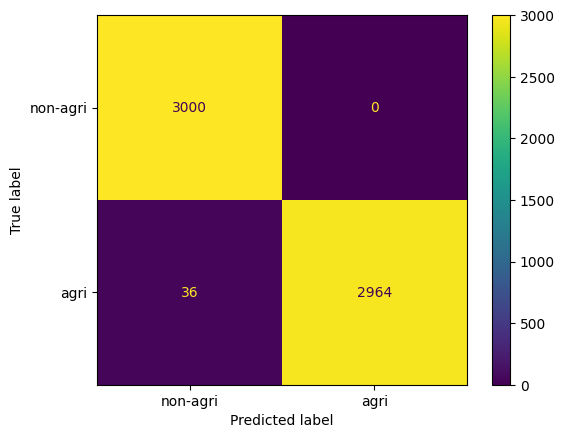

In [193]:
print_metrics(y_true=all_labels_keras,
              y_pred=all_preds_keras,
              y_prob=all_probs_keras,
              class_labels=agri_class_labels,
              model_name="Keras CNN-ViT Hybrid Model")

<a id="pytorch-metrics-reporting"></a>

#### PyTorch metrics reporting


Let's print the evaluation metrics using `print_metrics` function for the **PyTorch** ViT model with model name `PyTorch CNN-Vit Hybrid Model`


Evaluation metrics for the PyTorch CNN-ViT Hybrid Model
Accuracy:  0.9992
ROC-AUC:   1.0000
Loss:      0.0032

Classification report:

                precision    recall  f1-score   support

    non-agri     0.9983    1.0000    0.9992      3000
        agri     1.0000    0.9983    0.9992      3000

    accuracy                         0.9992      6000
   macro avg     0.9992    0.9992    0.9992      6000
weighted avg     0.9992    0.9992    0.9992      6000

========= Confusion Matrix =========


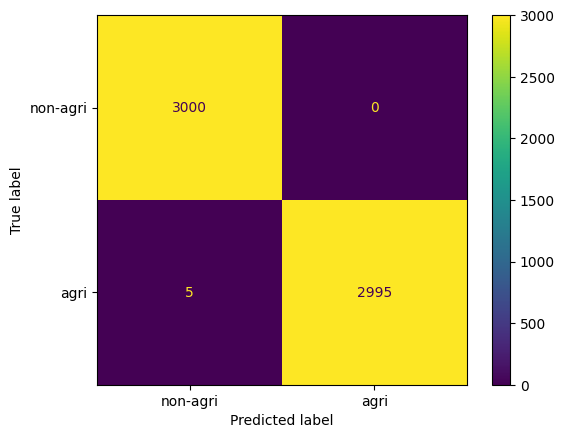

In [194]:
## Please use the space below to write your answer
print_metrics(y_true=all_labels_pytorch,
              y_pred=all_preds_pytorch,
              y_prob= np.array(all_probs_pytorch),
              class_labels=agri_class_labels,
              model_name="PyTorch CNN-ViT Hybrid Model")

<a id="hybrid-model-roc-curve-plotting"></a>

#### Hybrid Model ROC curve plotting

First, define a function to plot ROC curves for binary or multi-class classification using scikit-learn's `roc_curve` and `roc_auc_score`. It handles both single-class and multi-class cases by binarizing labels if needed.

Next, plot the ROC curves for both the models.


In [195]:

def plot_roc(y_true, y_prob, model_name):
    n_classes = y_prob.shape[1] if y_prob.ndim > 1 else 1
    if n_classes == 1:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})')
    else:
        y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
            auc = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
            plt.plot(fpr, tpr, label=f'{model_name} class {i} (AUC = {auc:.4f})')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()

Plot the ROC curves for both Keras and PyTorch models on the same figure for visual performance comparison.


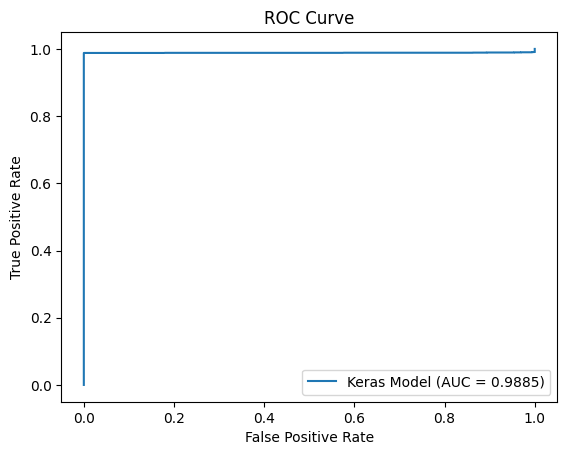

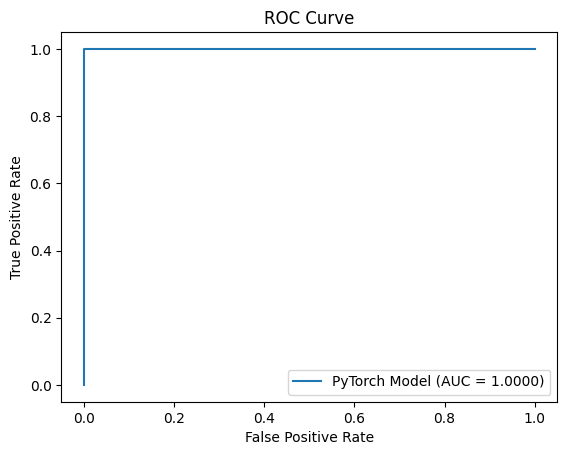

In [196]:
plot_roc(np.array(all_labels_keras), np.array(all_probs_keras[:, 1]), "Keras Model")
plt.show()
plot_roc(np.array(all_labels_pytorch), np.array(all_probs_pytorch), "PyTorch Model")
plt.show()

<a id="comparing-hybrid-model-performance"></a>

#### Comparing hybrid model performance

Now let's compare the performance of different models to understand which model would be the best performer for your land classification task.
Computed metrics for both models are used to generate a comparison table for key scores. This facilitates quick performance assessment between frameworks.


In [197]:
# get the Keras model performance metrics
metrics_keras = model_metrics(all_labels_keras, all_preds_keras, all_probs_keras, agri_class_labels)

# get the PyTorch model performance metrics
metrics_pytorch = model_metrics(all_labels_pytorch, all_preds_pytorch, all_probs_pytorch, agri_class_labels)


# Display the comparison of metrics
print("{:<18} | {:<15} {:<15}".format('\033[1m'+ 'Metric' + '\033[0m',
                                    'Keras Model', 
                                    'PyTorch Model'))
print(("".join(["-" for _ in range(43)])))
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

for k in metrics_list:
    print("{:<18} | {:<15.4f} {:<15.4f}".format('\033[1m'+k+'\033[0m',
                                              metrics_keras[k],
                                              metrics_pytorch[k]))

Metric     | Keras Model     PyTorch Model  
-------------------------------------------
Accuracy   | 0.9940          0.9992         
Precision  | 1.0000          1.0000         
Recall     | 0.9880          0.9983         
F1 Score   | 0.9940          0.9992         
ROC-AUC    | 0.9885          1.0000         


<a id="hybrid-model-metric-analysis"></a>

#### Hybrid Model Metric analysis

The metrics for the CNN-Vit Hybrid Keras and PyTorch models for evaluating the provided dataset are:

- **Accuracy**
    1. Keras: 0.9940
    2. PyTorch: 0.9992
    
    ===> Both models achieve exceptional accuracy, but the **PyTorch model makes fewer mistakes**.

- **Precision**
    1. Keras: 1.0000
    2. PyTorch: 1.0000

    ===> Both models perfectly **avoid false positives**.

- **Recall**
    1. Keras: 0.9880
    2. PyTorch: 0.9983
    
    ===> The **PyTorch** model is marginally better at **identifying all true positives**, capturing nearly all actual positive cases, while the Keras model misses a few.

- **F1 Score**
    1. Keras: 0.9940
    2. PyTorch: 0.9992
    
    ===> The F1 score, which balances precision and recall, favors the **PyTorch** model thanks to its **stronger recall**.

- **ROC-AUC**
    1. Keras: 0.9885
    2. PyTorch: 1.0000
    
    ===> The PyTorch model reaches maximum possible **discrimination between classes**, indicating outstanding capability for binary classification.


<a id="closing-remarks"></a>

## Closing Remarks
Throughout this notebook, we have observed the processes behind developing a Convolutional Neural Network using both Keras and PyTorch. We were then able to take our trained CNN and build a hybrid CNN-Vision Transformer model that added global context modeling. Below are some final comments regarding the two model styles we built during this project.

**CNN Model Results:**
- Achieved ~99.4% accuracy with strong precision/recall balance
- Excellent at capturing local spatial patterns in satellite imagery
- Computationally efficient with faster training/inference

**CNN-ViT Hybrid Model Results:**  
- Slightly lower performance (~99.0% accuracy in your trained version)
- Adds global context modeling through transformer attention
- More complex architecture requiring careful hyperparameter tuning

### Key Trade-offs

**Why CNN might outperform hybrid:**
- **Dataset size**: Your dataset may be too small for the hybrid to fully leverage transformer benefits
- **Training epochs**: CNN converged faster and better with limited training
- **Architecture fit**: Pure CNN is well-suited for this binary land classification task
- **Overhead**: Hybrid adds complexity without proportional gains on simpler tasks

**Potential advantages of hybrid approach:**
- **Scalability**: Better performance on larger datasets with more complex patterns
- **Global context**: Captures long-range dependencies that CNNs miss
- **Flexibility**: Adaptable to multi-class or more varied geospatial tasks

### Final Recommendations

For our current binary classification task, the pure CNN appears optimal. If expanding to more complex geospatial analysis (multi-class, temporal, or higher resolution), we should consider:
- Training hybrid longer with more data
- Fine-tuning transformer hyperparameters
- Exploring intermediate architectures
- Increase model interpretability
    - Adding attention visualization or GradCAM to show which image regions influence predictions
    - Feature map visualization would help understand what the CNN learns
- Improve scalability
    - For larger datasets, could add distributed training capabilities

The ~0.4% performance difference is minimal - both models achieve excellent results for land classification. Our CNN implementation demonstrates strong foundational skills in computer vision for geospatial applications.

<a id="about"></a>

## About
Written by David Lepore, with the assistance of instructors, for IBM's **AI Capstone Project with Deep Learning** course on Coursera. This was the 6th and final course in the **IBM Deep Learning with PyTorch, Keras, and Tensorflow Professional Certificate**. This is also the half-way point for the **IBM AI Engineering Professional Certificate**.